# Imports

In [ ]:
import os
import datetime
import pandas as pd
import pathlib as pl
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
import itertools
from scipy.stats import pearsonr
from scipy import stats
from pycaret.classification import * 
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform
import numpy as np
from imblearn.over_sampling import SMOTE
from imblearn.over_sampling im port RandomOverSampler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import json
from sklearn.model_selection import StratifiedKFold, learning_curve

# Functions

In [2]:
def delete_columns(dataset):
    lista_columns_vis = [i for i in dataset.columns if "STD" in i or "MIN" in i or "MAX" in i or "VAR" in i or "MEDIAN" in i or "95PERCENTILE" in i or "SUM" in i]
    dataset.drop(columns=lista_columns_vis, inplace=True)
    return dataset

In [3]:
def plot_class_distribution(df, dataset_name, column):
    # Get counts and sort by the class label (index)
    class_counts = df[column].value_counts().sort_index()
    total = class_counts.sum()
    percentages = (class_counts / total) * 100

    color_palette = sns.color_palette("Blues", len(class_counts))

    ax = sns.barplot(
        x=class_counts.index,
        y=class_counts.values,
        palette=color_palette
    )

    # Add labels above each bar
    for i, (cls, count) in enumerate(class_counts.items()):
        perc = percentages.loc[cls]
        ax.text(i, count, f"({perc:.1f}%) \n {count}",
                ha="center", va="bottom", fontsize=10)

    ax.set_xlabel(column, fontsize=12)
    ax.set_ylabel("Count", fontsize=12)
    ax.set_title(f"{dataset_name} Class Distribution", fontsize=14, pad=20)

    sns.despine()
    plt.show()

In [4]:
def reclassificar_columnas(df, columnas):
    for columna in columnas:
        df[columna] = df[columna].replace({1: 1, 2: 1, 3: 1, 4: 1, 5: 1, 6: 2, 7: 2, 8: 2, 9: 2})
    return df

In [5]:
def balance_dataset_oversampling(df, target_column='BL', oversampling_factor=0.5):
    if not 0.0 <= oversampling_factor <= 1.0:
        raise ValueError("oversampling_factor debe estar entre 0.0 y 1.0")

    X = df.drop(columns=[target_column])
    y = df[target_column]

    if y.isnull().any():
        raise ValueError("La columna objetivo contiene valores nulos.")
    if not pd.api.types.is_integer_dtype(y):
        y = y.astype(int)

    print("Distribución antes del oversampling:\n", y.value_counts())

    class_counts = y.value_counts()
    max_class = class_counts.max()
    sampling_strategy = {
        cls: count + int((max_class - count) * oversampling_factor)
        if count < max_class else count
        for cls, count in class_counts.items()
    }

    ros = RandomOverSampler(sampling_strategy=sampling_strategy, random_state=42)
    X_resampled, y_resampled = ros.fit_resample(X, y)

    print("Distribución después del oversampling:\n", pd.Series(y_resampled).value_counts())

    df_resampled = pd.concat([X_resampled, y_resampled.rename(target_column)], axis=1)
    return df_resampled.sample(frac=1.0, random_state=42).reset_index(drop=True)


In [6]:
cmap = sns.cubehelix_palette(8, start=.5, rot=-.75, as_cmap=True)
def correlaciones(dataframe,lista_corr):
    for i in lista_corr:
        corr = dataframe.corr(method=i)
        #Create a correlation matrix. Only bottom left corner valued.
        mask = np.zeros_like(corr.round(6))
        mask[np.triu_indices_from(mask)] = True

        # # Generate the corrleation matrix (heatmap) using Seaborn.
        with sns.axes_style("whitegrid"):
            f, ax = plt.subplots(figsize=(12, 10))
            ax = sns.heatmap(corr.round(4),
                            mask=mask,
                            vmax=1,
                            center = 0,
                            vmin=-1,
                            square=True,
                            cmap=cmap,
                            linewidths=.5,
                            annot=True,
                            annot_kws={"size": 12},
                            fmt='.2f')

            plt.xlabel('Features', fontsize=15)
            plt.ylabel('Features', fontsize=15)
            plt.title(f'Heatmap for {i.capitalize()} Correlations of the Features', fontsize=15)
        plt.show()

In [7]:
def _arr_size(x):
    try:
        return np.array(x).size
    except Exception:
        return 0

def estimate_param_count(model):
    # 1) Ensembles: sum tree/estimator params
    if hasattr(model, "estimators_") and getattr(model, "estimators_", None) is not None:
        total = 0
        for est in np.array(model.estimators_, dtype=object).ravel():
            if est is not None:
                total += estimate_param_count(est)
        if total > 0:
            return total

    # 2) Single tree models
    if hasattr(model, "tree_") and getattr(model, "tree_", None) is not None:
        return int(model.tree_.node_count)

    # 3) Linear/other fitted parameter arrays
    total = 0
    for attr in ["coef_", "intercept_", "feature_importances_", "singular_values_"]:
        if hasattr(model, attr):
            total += _arr_size(getattr(model, attr))
    if total > 0:
        return int(total)

    # 4) Fallback: hyperparameter count
    try:
        return len(model.get_params(deep=True))
    except Exception:
        return 1

In [8]:
def xgb_complexity(model):
    """
    Returns a dict with tree-based complexity stats for a fitted XGBoost model.
    Works for XGBClassifier/XGBRegressor and most wrappers that expose get_booster().
    """
    # unwrap common wrappers
    if hasattr(model, "named_steps"):  # pipeline
        # last step is usually the estimator
        model = list(model.named_steps.values())[-1]

    if hasattr(model, "get_booster"):
        booster = model.get_booster()
    elif hasattr(model, "booster_"):
        booster = model.booster_
    else:
        raise ValueError("This model doesn't look like a fitted XGBoost sklearn model.")

    # dump trees as JSON
    trees = booster.get_dump(dump_format="json")
    n_trees = len(trees)

    def count_nodes_and_leaves(tree_json):
        node_count = 0
        leaf_count = 0

        def walk(node):
            nonlocal node_count, leaf_count
            node_count += 1
            if "leaf" in node:
                leaf_count += 1
                return
            # internal node
            for child in node.get("children", []):
                walk(child)

        walk(json.loads(tree_json))
        return node_count, leaf_count

    total_nodes = 0
    total_leaves = 0
    for t in trees:
        n, l = count_nodes_and_leaves(t)
        total_nodes += n
        total_leaves += l

    return {
        "xgb_n_trees": n_trees,
        "xgb_total_nodes": total_nodes,
        "xgb_total_leaves": total_leaves,
        # pick one scalar complexity for bubble size:
        "complexity": total_nodes
    }

import numpy as np

def lgbm_complexity(model):
    """
    Returns tree-based complexity stats for a fitted LightGBM model.
    Works for LGBMClassifier/LGBMRegressor and wrappers exposing booster_.
    """
    # unwrap common wrappers
    if hasattr(model, "named_steps"):  # pipeline
        model = list(model.named_steps.values())[-1]

    if hasattr(model, "booster_"):
        booster = model.booster_
    elif hasattr(model, "_Booster"):
        booster = model._Booster
    else:
        raise ValueError("This model doesn't look like a fitted LightGBM sklearn model.")

    dump = booster.dump_model()
    tree_info = dump.get("tree_info", [])
    n_trees = len(tree_info)

    total_nodes = 0
    total_leaves = 0

    for t in tree_info:
        # LightGBM provides these directly
        total_leaves += t.get("num_leaves", 0)
        total_nodes += t.get("num_leaves", 0) - 1 if t.get("num_leaves", 0) else 0  # approx splits
        # if you want exact nodes, you can traverse tree_structure, but this is fast & stable

    # If you want exact node counting, use traversal (optional)
    # For most cases, num_leaves is an excellent complexity proxy.

    return {
        "lgbm_n_trees": n_trees,
        "lgbm_total_leaves": total_leaves,
        "lgbm_total_nodes_approx": total_nodes,
        "complexity": total_leaves
    }

def model_complexity(model):
    name = type(model).__name__.lower()

    # Pipeline unwrap
    if hasattr(model, "named_steps"):
        model = list(model.named_steps.values())[-1]
        name = type(model).__name__.lower()

    # XGBoost
    if hasattr(model, "get_booster") or hasattr(model, "booster_"):
        try:
            return xgb_complexity(model)["complexity"]
        except Exception:
            pass

    # LightGBM
    if hasattr(model, "booster_") or hasattr(model, "_Booster"):
        try:
            return lgbm_complexity(model)["complexity"]
        except Exception:
            pass

    # sklearn ensembles
    if hasattr(model, "estimators_") and model.estimators_ is not None:
        total = 0
        for est in np.array(model.estimators_, dtype=object).ravel():
            if est is not None and hasattr(est, "tree_"):
                total += int(est.tree_.node_count)
        if total > 0:
            return total

    # single tree
    if hasattr(model, "tree_") and model.tree_ is not None:
        return int(model.tree_.node_count)

    # linear-ish fallback
    total = 0
    for attr in ["coef_", "intercept_", "feature_importances_", "singular_values_"]:
        if hasattr(model, attr):
            try:
                total += np.array(getattr(model, attr)).size
            except Exception:
                pass
    if total > 0:
        return int(total)

    # last resort
    try:
        return len(model.get_params(deep=True))
    except Exception:
        return 1


# Datasets DF BLAST

## 2 Classes

In [10]:
df_blast_2022_BL2_class = pd.read_excel(r"D:\OneDrive - CGIAR\Documents\Projects\Rice\BLAST PROJECT\2025\DATA\Dataframes\df_blast_2022_BL2_class.xlsx")
df_blast_2023_BL2_class = pd.read_excel(r"D:\OneDrive - CGIAR\Documents\Projects\Rice\BLAST PROJECT\2025\DATA\Dataframes\df_blast_2023_BL2_class.xlsx")
df_blast_2024_BL2_class = pd.read_excel(r"D:\OneDrive - CGIAR\Documents\Projects\Rice\BLAST PROJECT\2025\DATA\Dataframes\df_blast_2024_BL2_class.xlsx")
df_blast_2025_BL2_class = pd.read_excel(r"D:\OneDrive - CGIAR\Documents\Projects\Rice\BLAST PROJECT\2025\DATA\Dataframes\df_blast_2025_BL2_class.xlsx")
df_blast_2022_2023_2024_BL2_class = pd.read_excel(r"D:\OneDrive - CGIAR\Documents\Projects\Rice\BLAST PROJECT\2025\DATA\Dataframes\df_blast_2022_2023_2024_BL2_class.xlsx")
df_blast_2022_2023_2024_oversampled_BL2_class = pd.read_excel(r"D:\OneDrive - CGIAR\Documents\Projects\Rice\BLAST PROJECT\2025\DATA\Dataframes\df_blast_2022_2023_2024_oversampled_BL2_class.xlsx") 
df_blast_2022_2023_2024_2025_BL2_class = pd.read_excel(r"D:\OneDrive - CGIAR\Documents\Projects\Rice\BLAST PROJECT\2025\DATA\Dataframes\df_blast_2022_2023_2024_2025_BL2_class.xlsx")

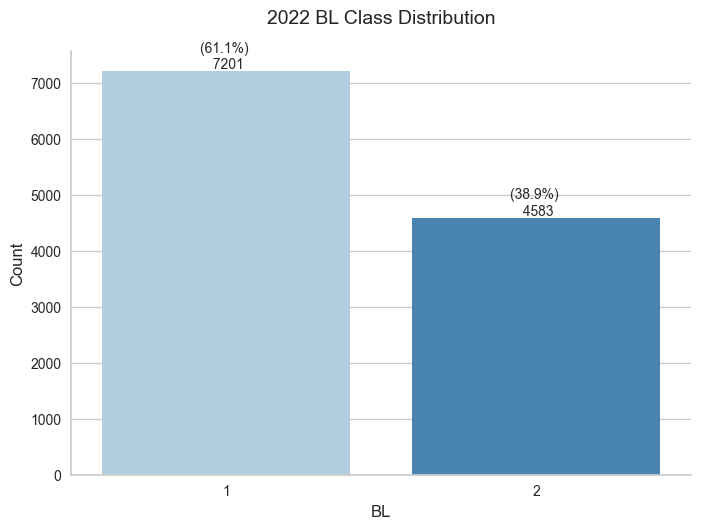

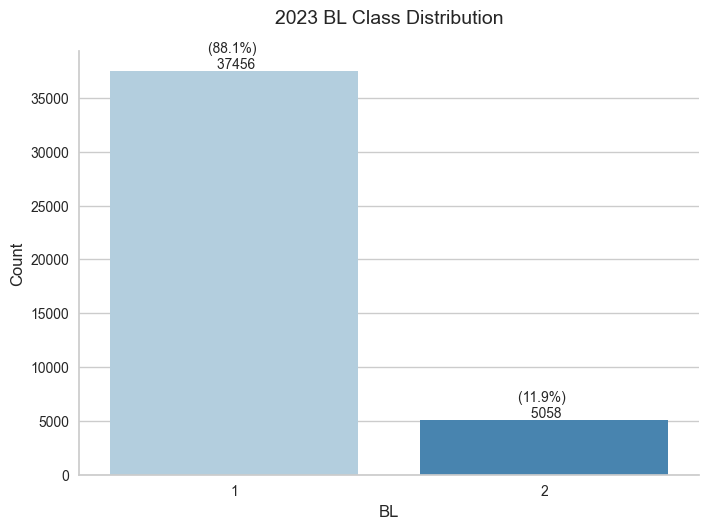

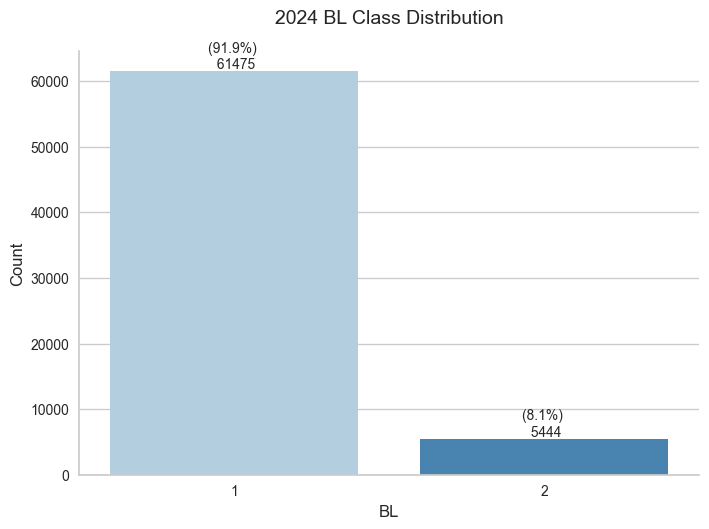

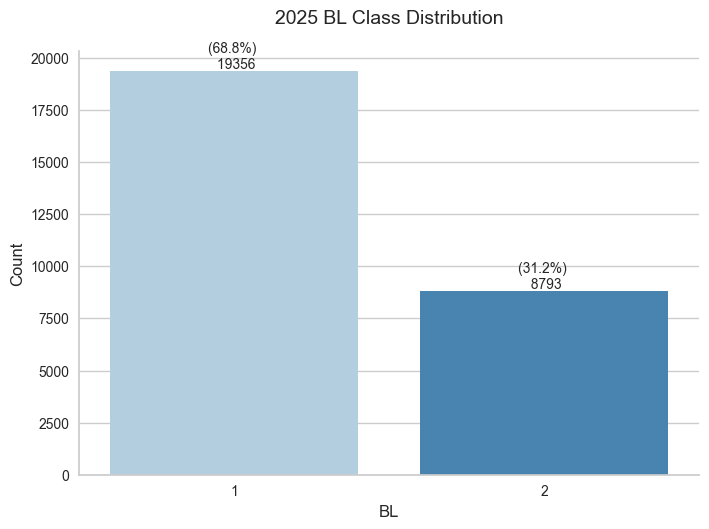

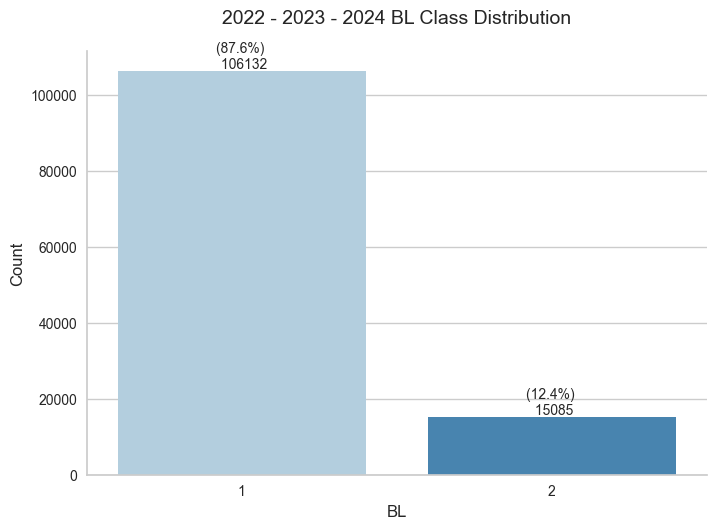

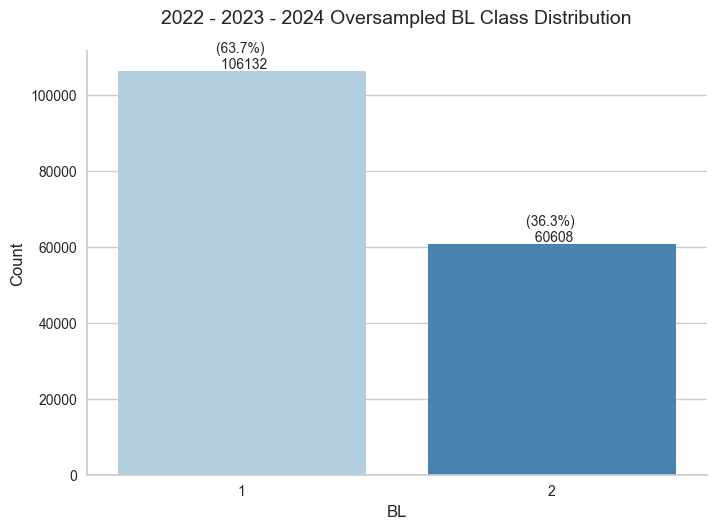

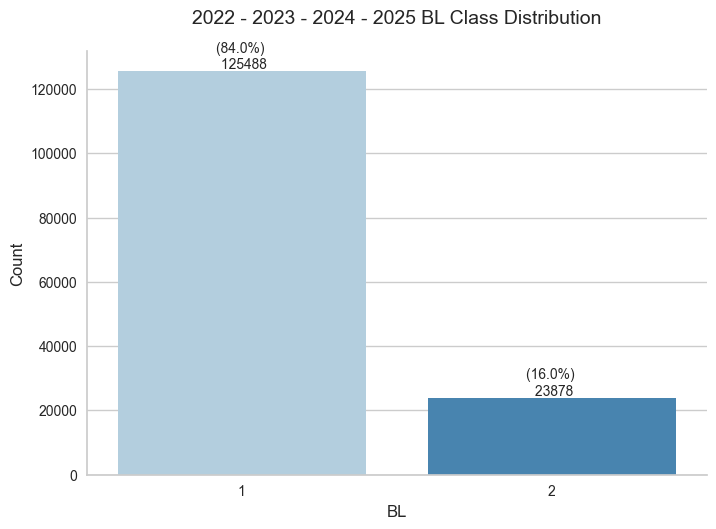

In [11]:
plot_class_distribution(df_blast_2022_BL2_class, dataset_name = "2022 BL", column ="BL")
plot_class_distribution(df_blast_2023_BL2_class, dataset_name = "2023 BL", column ="BL")
plot_class_distribution(df_blast_2024_BL2_class, dataset_name = "2024 BL", column ="BL")
plot_class_distribution(df_blast_2025_BL2_class, dataset_name = "2025 BL", column ="BL")
plot_class_distribution(df_blast_2022_2023_2024_BL2_class, dataset_name = "2022 - 2023 - 2024 BL", column ="BL")
plot_class_distribution(df_blast_2022_2023_2024_oversampled_BL2_class, dataset_name = "2022 - 2023 - 2024 Oversampled BL", column ="BL")
plot_class_distribution(df_blast_2022_2023_2024_2025_BL2_class, dataset_name = "2022 - 2023 - 2024 - 2025 BL", column ="BL")

### Oversampling df_blast_2025

Distribución antes del oversampling:
 BL
1    19356
2     8793
Name: count, dtype: int64
Distribución después del oversampling:
 BL
1    19356
2    19356
Name: count, dtype: int64


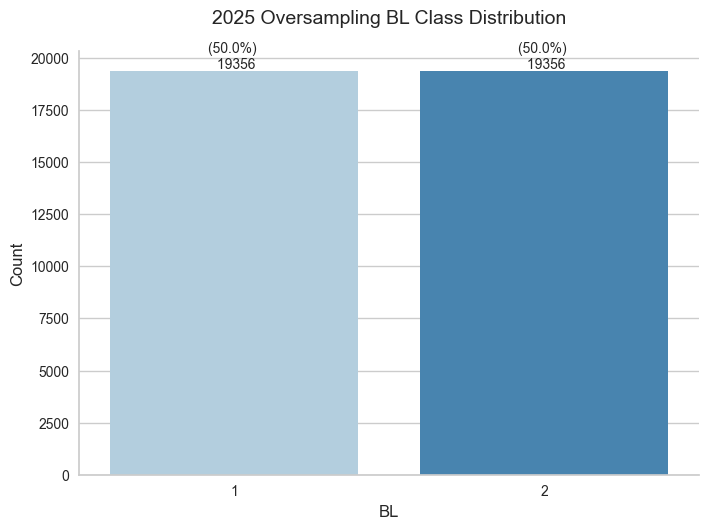

In [12]:
df_blast_2025_oversampling_BL2_class = balance_dataset_oversampling(df_blast_2025_BL2_class, target_column='BL', oversampling_factor=1)
plot_class_distribution(df_blast_2025_oversampling_BL2_class, dataset_name = "2025 Oversampling BL", column ="BL")

### Clean Features

#### df_blast_2025_BL2_class

In [13]:
df_blast_2025_BL2_class.head(1)

,BL,NDRE_MEAN,NDVI_MEAN,GNDVI_MEAN,BNDVI_MEAN,NDREI_MEAN,NPCI_MEAN,GRVI_MEAN,NGBDI_MEAN,CH_MEAN,CV_MEAN,CC_%,CC_mt2
0,1,0.402884,0.645484,0.49694,0.584175,0.350823,0.248622,0.242076,0.131727,326.98413,0.027359,76.54895,1.085678


In [14]:
variables_no_Canopy = ['BL','NDRE_MEAN', 'NDVI_MEAN', 'GNDVI_MEAN', 'BNDVI_MEAN', 'NDREI_MEAN', 'NPCI_MEAN', 'GRVI_MEAN', 'NGBDI_MEAN']
df_blast_2025_BL2_class = df_blast_2025_BL2_class[variables_no_Canopy]
print('df_blast_2025_BL2_class:',df_blast_2025_BL2_class.shape)

df_blast_2025_BL2_class: (28149, 9)


In [15]:
df_blast_2025_BL2_class.head(1)

,BL,NDRE_MEAN,NDVI_MEAN,GNDVI_MEAN,BNDVI_MEAN,NDREI_MEAN,NPCI_MEAN,GRVI_MEAN,NGBDI_MEAN
0,1,0.402884,0.645484,0.49694,0.584175,0.350823,0.248622,0.242076,0.131727


#### df_blast_2022_2023_2024_BL2_class

In [16]:
df_blast_2022_2023_2024_BL2_class.head(1)

,BL,NDRE_MEAN,NDVI_MEAN,GNDVI_MEAN,BNDVI_MEAN,NDREI_MEAN,NPCI_MEAN,GRVI_MEAN,NGBDI_MEAN,CH_MEAN,CV_MEAN,CC_%,CC_mt2
0,2,-0.063189,0.310896,-0.002796,0.107131,0.368609,0.169279,0.323468,0.112283,259.77396,0.044318,64.0986,0.852622


In [17]:
variables_no_Canopy = ['BL','NDRE_MEAN', 'NDVI_MEAN', 'GNDVI_MEAN', 'BNDVI_MEAN', 'NDREI_MEAN', 'NPCI_MEAN', 'GRVI_MEAN', 'NGBDI_MEAN']
df_blast_2022_2023_2024_BL2_class = df_blast_2022_2023_2024_BL2_class[variables_no_Canopy]
print('df_blast_2022_2023_2024_BL2_class:',df_blast_2022_2023_2024_BL2_class.shape)

df_blast_2022_2023_2024_BL2_class: (121217, 9)


In [18]:
df_blast_2022_2023_2024_BL2_class.head(1)

,BL,NDRE_MEAN,NDVI_MEAN,GNDVI_MEAN,BNDVI_MEAN,NDREI_MEAN,NPCI_MEAN,GRVI_MEAN,NGBDI_MEAN
0,2,-0.063189,0.310896,-0.002796,0.107131,0.368609,0.169279,0.323468,0.112283


## 3 Classes

In [19]:
df_blast_2022_BL3_class = pd.read_excel(r"D:\OneDrive - CGIAR\Documents\Projects\Rice\BLAST PROJECT\2025\DATA\Dataframes\df_blast_2022_BL3_class.xlsx")
df_blast_2023_BL3_class = pd.read_excel(r"D:\OneDrive - CGIAR\Documents\Projects\Rice\BLAST PROJECT\2025\DATA\Dataframes\df_blast_2023_BL3_class.xlsx")
df_blast_2024_BL3_class = pd.read_excel(r"D:\OneDrive - CGIAR\Documents\Projects\Rice\BLAST PROJECT\2025\DATA\Dataframes\df_blast_2024_BL3_class.xlsx")
df_blast_2025_BL3_class = pd.read_excel(r"D:\OneDrive - CGIAR\Documents\Projects\Rice\BLAST PROJECT\2025\DATA\Dataframes\df_blast_2025_BL3_class.xlsx")
df_blast_2022_2023_2024_BL3_class = pd.read_excel(r"D:\OneDrive - CGIAR\Documents\Projects\Rice\BLAST PROJECT\2025\DATA\Dataframes\df_blast_2022_2023_2024_BL3_class.xlsx")
df_blast_2022_2023_2024_oversampled_BL3_class = pd.read_excel(r"D:\OneDrive - CGIAR\Documents\Projects\Rice\BLAST PROJECT\2025\DATA\Dataframes\df_blast_2022_2023_2024_oversampled_BL3_class.xlsx")
df_blast_2022_2023_2024_2025_BL3_class = pd.read_excel(r"D:\OneDrive - CGIAR\Documents\Projects\Rice\BLAST PROJECT\2025\DATA\Dataframes\df_blast_2022_2023_2024_2025_BL3_class.xlsx")

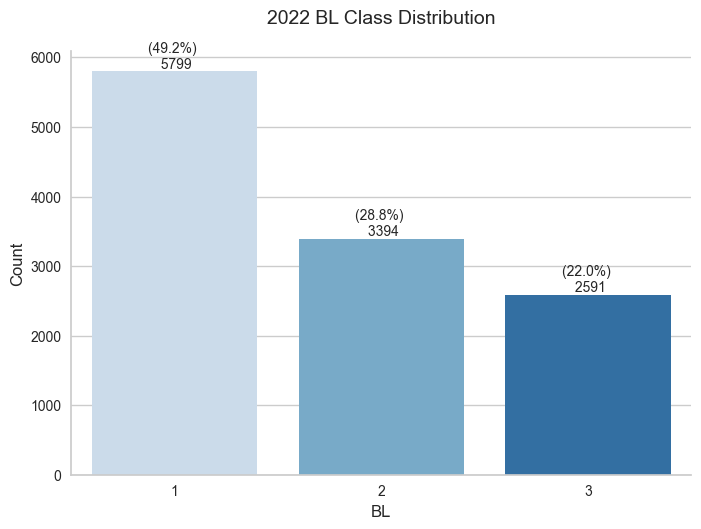

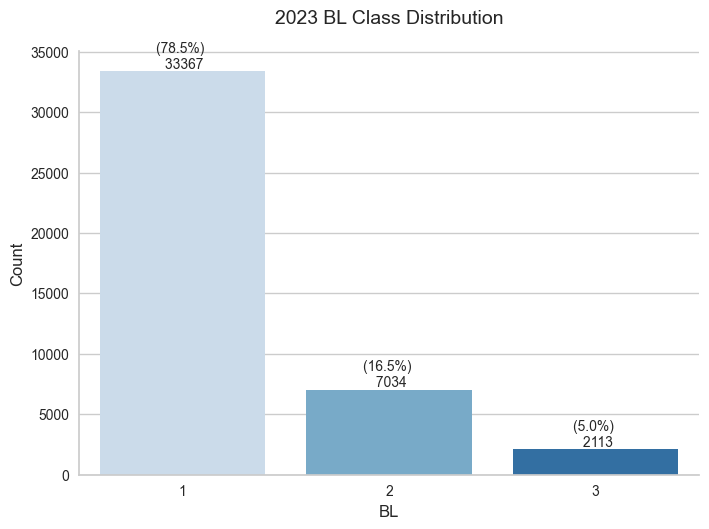

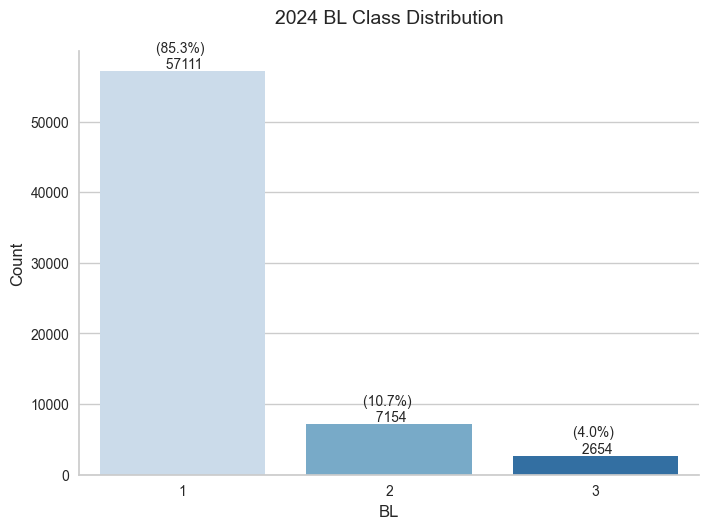

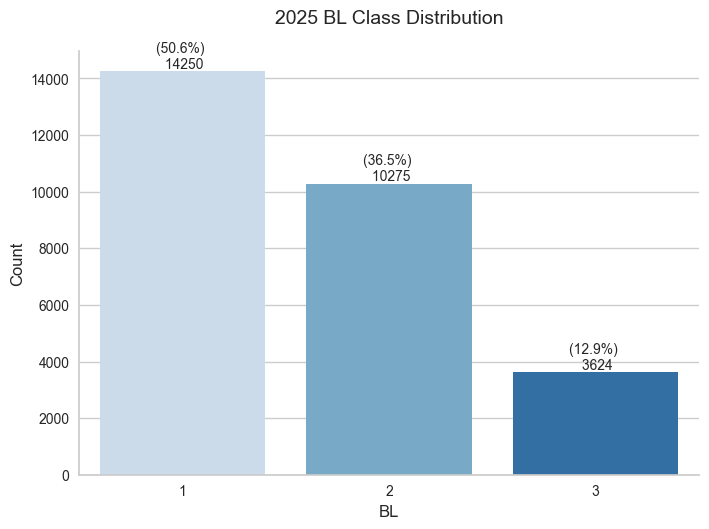

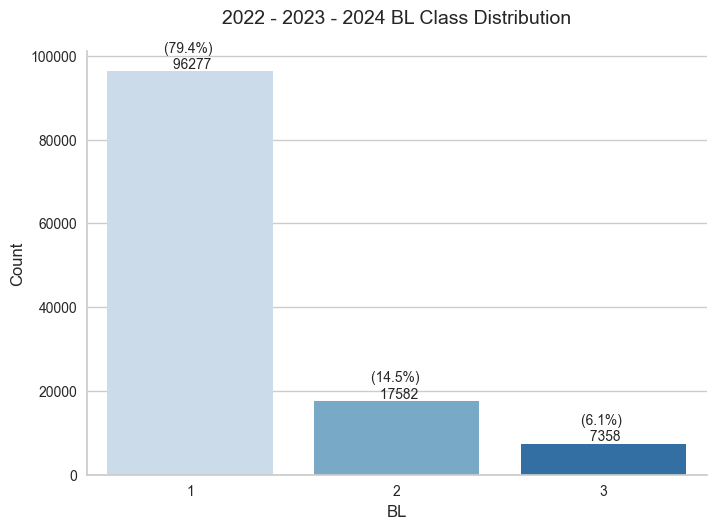

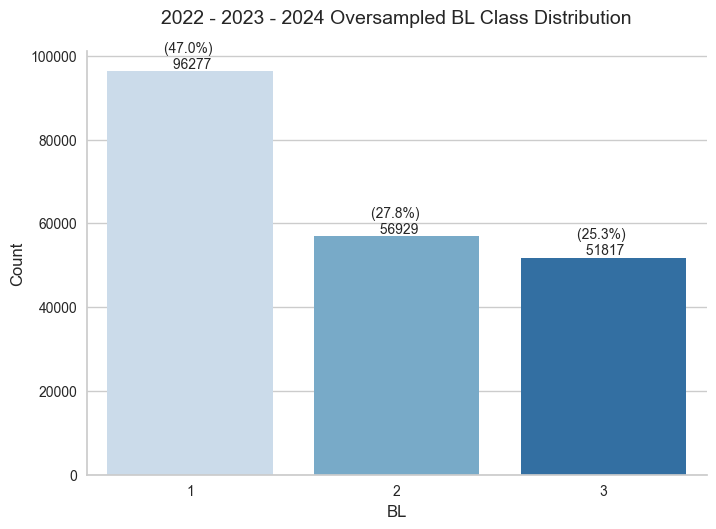

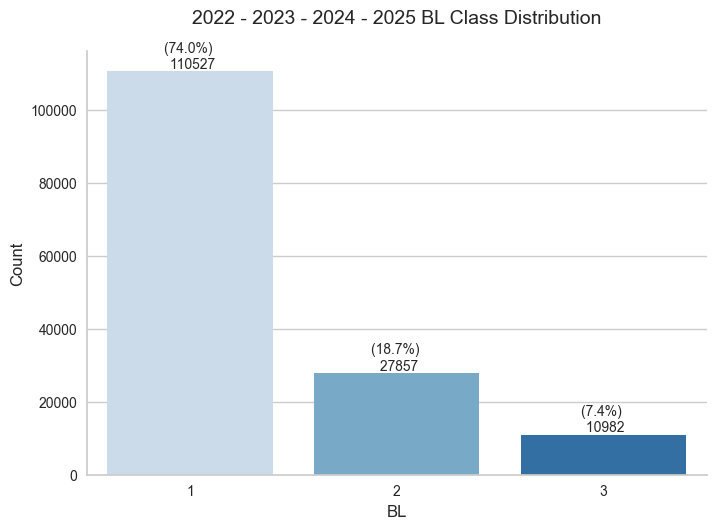

In [20]:
plot_class_distribution(df_blast_2022_BL3_class, dataset_name = "2022 BL", column ="BL")
plot_class_distribution(df_blast_2023_BL3_class, dataset_name = "2023 BL", column ="BL")
plot_class_distribution(df_blast_2024_BL3_class, dataset_name = "2024 BL", column ="BL")
plot_class_distribution(df_blast_2025_BL3_class, dataset_name = "2025 BL", column ="BL")
plot_class_distribution(df_blast_2022_2023_2024_BL3_class, dataset_name = "2022 - 2023 - 2024 BL", column ="BL")
plot_class_distribution(df_blast_2022_2023_2024_oversampled_BL3_class, dataset_name = "2022 - 2023 - 2024 Oversampled BL", column ="BL")
plot_class_distribution(df_blast_2022_2023_2024_2025_BL3_class, dataset_name = "2022 - 2023 - 2024 - 2025 BL", column ="BL")

### Clean Features

#### df_blast_2025_BL3_class

In [21]:
df_blast_2025_BL3_class.head(1)

,BL,NDRE_MEAN,NDVI_MEAN,GNDVI_MEAN,BNDVI_MEAN,NDREI_MEAN,NPCI_MEAN,GRVI_MEAN,NGBDI_MEAN,CH_MEAN,CV_MEAN,CC_%,CC_mt2
0,1,0.402884,0.645484,0.49694,0.584175,0.350823,0.248622,0.242076,0.131727,326.98413,0.027359,76.54895,1.085678


In [22]:
variables_no_Canopy = ['BL','NDRE_MEAN', 'NDVI_MEAN', 'GNDVI_MEAN', 'BNDVI_MEAN', 'NDREI_MEAN', 'NPCI_MEAN', 'GRVI_MEAN', 'NGBDI_MEAN']
df_blast_2025_BL3_class = df_blast_2025_BL3_class[variables_no_Canopy]
print('df_blast_2025_BL3_class:',df_blast_2025_BL3_class.shape)

df_blast_2025_BL3_class: (28149, 9)


In [23]:
df_blast_2025_BL3_class.head(1)

,BL,NDRE_MEAN,NDVI_MEAN,GNDVI_MEAN,BNDVI_MEAN,NDREI_MEAN,NPCI_MEAN,GRVI_MEAN,NGBDI_MEAN
0,1,0.402884,0.645484,0.49694,0.584175,0.350823,0.248622,0.242076,0.131727


#### df_blast_2022_2023_2024_BL3_class

In [24]:
df_blast_2022_2023_2024_BL3_class.head(1)

,BL,NDRE_MEAN,NDVI_MEAN,GNDVI_MEAN,BNDVI_MEAN,NDREI_MEAN,NPCI_MEAN,GRVI_MEAN,NGBDI_MEAN,CH_MEAN,CV_MEAN,CC_%,CC_mt2
0,2,-0.063189,0.310896,-0.002796,0.107131,0.368609,0.169279,0.323468,0.112283,259.77396,0.044318,64.0986,0.852622


In [25]:
variables_no_Canopy = ['BL','NDRE_MEAN', 'NDVI_MEAN', 'GNDVI_MEAN', 'BNDVI_MEAN', 'NDREI_MEAN', 'NPCI_MEAN', 'GRVI_MEAN', 'NGBDI_MEAN']
df_blast_2022_2023_2024_BL3_class = df_blast_2022_2023_2024_BL3_class[variables_no_Canopy]
print('df_blast_2022_2023_2024_BL3_class:',df_blast_2022_2023_2024_BL3_class.shape)

df_blast_2022_2023_2024_BL3_class: (121217, 9)


In [26]:
df_blast_2022_2023_2024_BL3_class.head(1)

,BL,NDRE_MEAN,NDVI_MEAN,GNDVI_MEAN,BNDVI_MEAN,NDREI_MEAN,NPCI_MEAN,GRVI_MEAN,NGBDI_MEAN
0,2,-0.063189,0.310896,-0.002796,0.107131,0.368609,0.169279,0.323468,0.112283


# Models

## Pycaret

### 2 Classes

#### Train & Test Data

In [27]:
from sklearn.model_selection import train_test_split

# Supongamos que `df` es tu DataFrame completo
df_train_BL2_class, df_test_BL2_class = train_test_split(df_blast_2022_2023_2024_BL2_class, test_size=0.3, random_state=24)

print(f"Tamaño del conjunto de entrenamiento BL2_class: {len(df_train_BL2_class)}")
print(f"Tamaño del conjunto de prueba BL2_class: {len(df_test_BL2_class)}")

BL_counts = df_train_BL2_class['BL'].value_counts()
print("df_train_BL2_class",BL_counts)

BL_counts = df_test_BL2_class['BL'].value_counts()
print("df_test_BL2_class", BL_counts)

Tamaño del conjunto de entrenamiento BL2_class: 84851
Tamaño del conjunto de prueba BL2_class: 36366
df_train_BL2_class BL
1    74313
2    10538
Name: count, dtype: int64
df_test_BL2_class BL
1    31819
2     4547
Name: count, dtype: int64


#### Train Data Oversampling

In [28]:
df_train_oversampling_BL2_class = balance_dataset_oversampling(df_train_BL2_class, target_column='BL', oversampling_factor=1)

Distribución antes del oversampling:
 BL
1    74313
2    10538
Name: count, dtype: int64
Distribución después del oversampling:
 BL
1    74313
2    74313
Name: count, dtype: int64


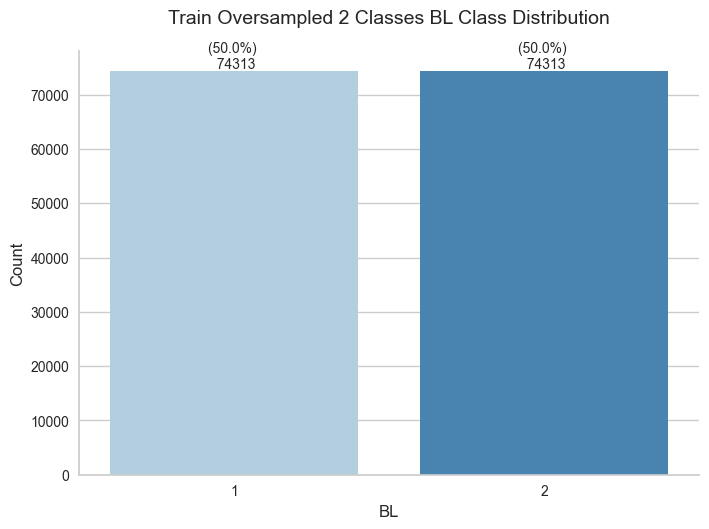

BL
1    74313
2    74313
Name: count, dtype: int64


In [29]:
plot_class_distribution(df_train_oversampling_BL2_class, dataset_name = "Train Oversampled 2 Classes BL", column ="BL")
BL_counts = df_train_oversampling_BL2_class['BL'].value_counts()
print(BL_counts)

#### Setup Model

In [30]:
model_blast_BL2_class = setup(data = df_train_oversampling_BL2_class,
                target ='BL',
                normalize = True, # Estaba en True
                remove_outliers = False,
                session_id= 8337,
                )

,Description,Value
0,Session id,8337
1,Target,BL
2,Target type,Binary
3,Target mapping,"1: 0, 2: 1"
4,Original data shape,"(148626, 9)"
5,Transformed data shape,"(148626, 9)"
6,Transformed train set shape,"(104038, 9)"
7,Transformed test set shape,"(44588, 9)"
8,Numeric features,8
9,Preprocess,True


#### Compare Models

In [30]:
models_BL2_class = compare_models(include=['et', 'rf', 'dt', 'knn', 'xgboost', 'lightgbm'])
df_models_BL2_class = pull()

,,
,,
Initiated,. . . . . . . . . . . . . . . . . .,10:30:34
Status,. . . . . . . . . . . . . . . . . .,Loading Dependencies
Estimator,. . . . . . . . . . . . . . . . . .,Compiling Library


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
et,Extra Trees Classifier,0.9774,0.9981,0.9774,0.9779,0.9774,0.9547,0.9553,2.2630
rf,Random Forest Classifier,0.9631,0.9971,0.9631,0.9650,0.9630,0.9261,0.9280,7.9940
dt,Decision Tree Classifier,0.9314,0.9314,0.9314,0.9384,0.9312,0.8629,0.8699,0.3530
knn,K Neighbors Classifier,0.8353,0.9116,0.8353,0.8501,0.8335,0.6706,0.6852,0.4040
xgboost,Extreme Gradient Boosting,0.7895,0.8769,0.7895,0.7903,0.7894,0.5791,0.5799,0.5430
lightgbm,Light Gradient Boosting Machine,0.7522,0.8386,0.7522,0.7566,0.7512,0.5044,0.5088,0.8120


In [31]:
et_model_BL2_class = create_model('et')
rf_model_BL2_class = create_model('rf')
dt_model_BL2_class = create_model('dt')
knn_model_BL2_class = create_model('knn')
xgboost_model_BL2_class = create_model('xgboost')
lightgbm_model_BL2_class = create_model('lightgbm')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9611,0.9964,0.9611,0.9631,0.9610,0.9221,0.9242
1,0.9656,0.9977,0.9656,0.9674,0.9656,0.9312,0.9330
2,0.9611,0.9976,0.9611,0.9634,0.9610,0.9221,0.9244
3,0.9648,0.9973,0.9648,0.9666,0.9648,0.9296,0.9314
4,0.9617,0.9973,0.9617,0.9638,0.9617,0.9235,0.9256
5,0.9627,0.9968,0.9627,0.9646,0.9627,0.9254,0.9273
6,0.9616,0.9972,0.9616,0.9638,0.9616,0.9233,0.9255
7,0.9613,0.9965,0.9613,0.9632,0.9612,0.9225,0.9245
8,0.9661,0.9973,0.9661,0.9677,0.9660,0.9321,0.9337


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9292,0.9292,0.9292,0.9365,0.9289,0.8583,0.8656
1,0.9335,0.9335,0.9335,0.9405,0.9332,0.8670,0.8740
2,0.9274,0.9274,0.9274,0.9355,0.9271,0.8549,0.8629
3,0.9344,0.9344,0.9344,0.9408,0.9342,0.8689,0.8753
4,0.9285,0.9285,0.9285,0.9364,0.9282,0.8570,0.8648
5,0.9313,0.9313,0.9313,0.9379,0.9310,0.8626,0.8692
6,0.9310,0.9310,0.9310,0.9383,0.9307,0.8620,0.8693
7,0.9320,0.9320,0.9320,0.9386,0.9318,0.8641,0.8706
8,0.9346,0.9346,0.9346,0.9410,0.9344,0.8693,0.8756


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.8351,0.9119,0.8351,0.8500,0.8333,0.6701,0.6849
1,0.8343,0.9120,0.8343,0.8486,0.8326,0.6686,0.6828
2,0.8317,0.9110,0.8317,0.8486,0.8296,0.6634,0.6801
3,0.8394,0.9125,0.8394,0.8538,0.8377,0.6788,0.6931
4,0.8320,0.9118,0.8320,0.8475,0.8301,0.6640,0.6793
5,0.8339,0.9078,0.8339,0.8493,0.8321,0.6678,0.6830
6,0.8357,0.9118,0.8357,0.8491,0.8342,0.6715,0.6847
7,0.8382,0.9115,0.8382,0.8534,0.8365,0.6765,0.6915
8,0.8372,0.9141,0.8372,0.8500,0.8356,0.6743,0.6871


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.7837,0.8739,0.7837,0.7843,0.7836,0.5675,0.5680
1,0.7845,0.8733,0.7845,0.7858,0.7843,0.5690,0.5703
2,0.7860,0.8724,0.7860,0.7864,0.7860,0.5721,0.5724
3,0.7951,0.8795,0.7951,0.7958,0.7950,0.5902,0.5909
4,0.7930,0.8799,0.7930,0.7938,0.7928,0.5859,0.5867
5,0.7870,0.8772,0.7870,0.7878,0.7869,0.5740,0.5748
6,0.7919,0.8735,0.7919,0.7923,0.7918,0.5838,0.5842
7,0.7849,0.8759,0.7849,0.7859,0.7847,0.5698,0.5708
8,0.7920,0.8803,0.7920,0.7931,0.7918,0.5840,0.5851


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.7446,0.8328,0.7446,0.7484,0.7436,0.4892,0.4930
1,0.7487,0.8349,0.7487,0.7534,0.7475,0.4973,0.5020
2,0.7506,0.8373,0.7506,0.7546,0.7496,0.5012,0.5052
3,0.7551,0.8413,0.7551,0.7594,0.7541,0.5102,0.5145
4,0.7516,0.8393,0.7516,0.7561,0.7505,0.5033,0.5077
5,0.7526,0.8404,0.7526,0.7559,0.7518,0.5052,0.5085
6,0.7562,0.8363,0.7562,0.7598,0.7554,0.5125,0.5160
7,0.7496,0.8370,0.7496,0.7549,0.7483,0.4992,0.5045
8,0.7519,0.8400,0.7519,0.7573,0.7506,0.5038,0.5092


#### Models Parameters

In [32]:
params_map = {
    "rf": estimate_param_count(rf_model_BL2_class),
    "et": estimate_param_count(et_model_BL2_class),
    "dt": estimate_param_count(dt_model_BL2_class),
    "knn": estimate_param_count(knn_model_BL2_class),
    "xgboost": estimate_param_count(xgboost_model_BL2_class),
    "lightgbm": estimate_param_count(lightgbm_model_BL2_class),
}

In [33]:
results_df = df_models_BL2_class.copy()

# In PyCaret, the index is usually model names; sometimes the "Model" column exists.
# This makes it robust:
if "Model" in results_df.columns:
    key_series = results_df["Model"].astype(str).str.lower()
else:
    key_series = results_df.index.astype(str).str.lower()

# Map based on keywords in the name
def match_params(name):
    if "random forest" in name or name == "rf":
        return params_map["rf"]
    if "extra trees" in name or "extremely randomized" in name or name == "et":
        return params_map["et"]
    if "decision tree" in name or name == "dt":
        return params_map["dt"]
    if "knn" in name or "k neighbors" in name or "nearest neighbors" in name:
        return params_map["knn"]
    if "xgboost" in name or "extreme gradient boosting" in name or "xgb" in name:
        return params_map["xgboost"]
    if "lightgbm" in name or "light gradient boosting" in name or "lgbm" in name:
        return params_map["lightgbm"]
    return None

results_df["Params"] = key_series.map(match_params)

# If any are missing, show them:
missing = results_df[results_df["Params"].isna()]
if len(missing) > 0:
    print("Rows missing Params mapping:\n", missing.index if "Model" not in missing.columns else missing["Model"])


In [34]:
complexity_map = {
    "Random Forest Classifier": model_complexity(rf_model_BL2_class),
    "Extra Trees Classifier": model_complexity(et_model_BL2_class),
    "Decision Tree Classifier": model_complexity(dt_model_BL2_class),
    "K Neighbors Classifier": model_complexity(knn_model_BL2_class),
    "Extreme Gradient Boosting": model_complexity(xgboost_model_BL2_class),
    "Light Gradient Boosting Machine": model_complexity(lightgbm_model_BL2_class),
}

results_df["Complexity"] = results_df["Model"].map(complexity_map)

In [35]:
results_df

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec),Params,Complexity
et,Extra Trees Classifier,0.9774,0.9981,0.9774,0.9779,0.9774,0.9547,0.9553,2.263,4384186,4384186
rf,Random Forest Classifier,0.9631,0.9971,0.9631,0.9650,0.9630,0.9261,0.9280,7.994,1804796,1804796
dt,Decision Tree Classifier,0.9314,0.9314,0.9314,0.9384,0.9312,0.8629,0.8699,0.353,17003,17003
knn,K Neighbors Classifier,0.8353,0.9116,0.8353,0.8501,0.8335,0.6706,0.6852,0.404,8,8
xgboost,Extreme Gradient Boosting,0.7895,0.8769,0.7895,0.7903,0.7894,0.5791,0.5799,0.543,9,9316
lightgbm,Light Gradient Boosting Machine,0.7522,0.8386,0.7522,0.7566,0.7512,0.5044,0.5088,0.812,8,3100


In [36]:
print("XGB:", xgb_complexity(xgboost_model_BL2_class))
print("LGBM:", lgbm_complexity(lightgbm_model_BL2_class))

XGB: {'xgb_n_trees': 100, 'xgb_total_nodes': 9316, 'xgb_total_leaves': 4708, 'complexity': 9316}
LGBM: {'lgbm_n_trees': 100, 'lgbm_total_leaves': 3100, 'lgbm_total_nodes_approx': 3000, 'complexity': 3100}


##### Training Time vs Accuracy

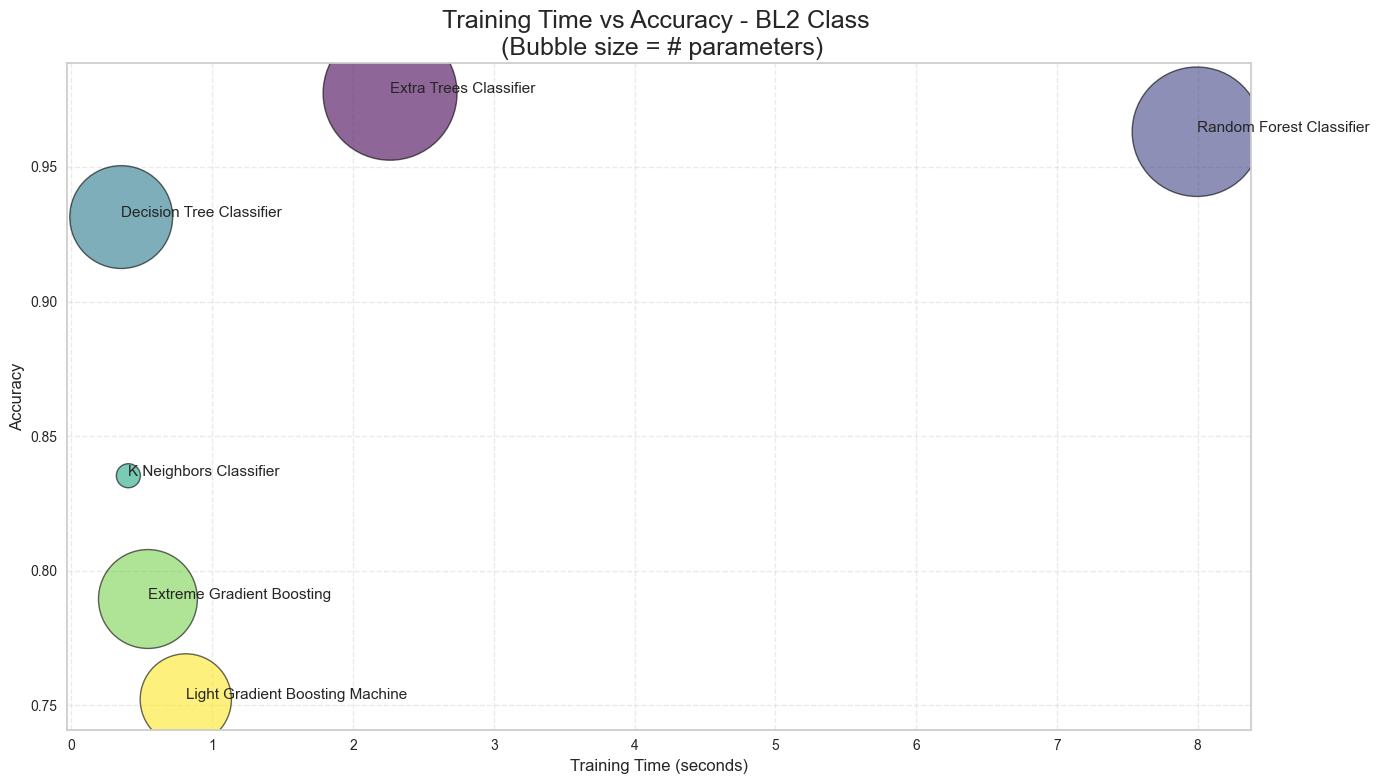

In [37]:
import matplotlib.pyplot as plt
import numpy as np

df = results_df.dropna(subset=["Params"]).copy()

x = df["TT (Sec)"]
y = df["Accuracy"]
labels = df.index if "Model" not in df.columns else df["Model"]
#sizes = df["Params"]
#sizes = np.log1p(results_df["Complexity"].astype(float)) * 1500

# Bubble scaling — tune this ONE line if needed
#bubble_sizes = sizes / (sizes.max() / 8000)  # auto-scale to nice range
#bubble_sizes = np.log1p(sizes) * 2000

sizes = df["Complexity"].astype(float)
s = np.log1p(sizes)

bubble_sizes = 300 + (s - s.min()) / (s.max() - s.min() + 1e-9) * 9000

plt.figure(figsize=(14, 8))

colors = np.linspace(0, 1, len(df))
plt.scatter(
    x, y,
    s=bubble_sizes,
    c=colors,
    cmap="viridis",
    alpha=0.6,
    edgecolors="black",
    linewidths=1
)

for i in range(len(df)):
    plt.text(x.iloc[i], y.iloc[i], str(labels.iloc[i] if hasattr(labels, "iloc") else labels[i]), fontsize=11)

plt.title("Training Time vs Accuracy - BL2 Class \n (Bubble size = # parameters)", fontsize=18)
plt.xlabel("Training Time (seconds)", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


#### Create Model

In [31]:
xgboost_model_BL2_class = create_model('xgboost')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.7837,0.8739,0.7837,0.7843,0.7836,0.5675,0.5680
1,0.7845,0.8733,0.7845,0.7858,0.7843,0.5690,0.5703
2,0.7860,0.8724,0.7860,0.7864,0.7860,0.5721,0.5724
3,0.7951,0.8795,0.7951,0.7958,0.7950,0.5902,0.5909
4,0.7930,0.8799,0.7930,0.7938,0.7928,0.5859,0.5867
5,0.7870,0.8772,0.7870,0.7878,0.7869,0.5740,0.5748
6,0.7919,0.8735,0.7919,0.7923,0.7918,0.5838,0.5842
7,0.7849,0.8759,0.7849,0.7859,0.7847,0.5698,0.5708
8,0.7920,0.8803,0.7920,0.7931,0.7918,0.5840,0.5851


#### Analyze Model

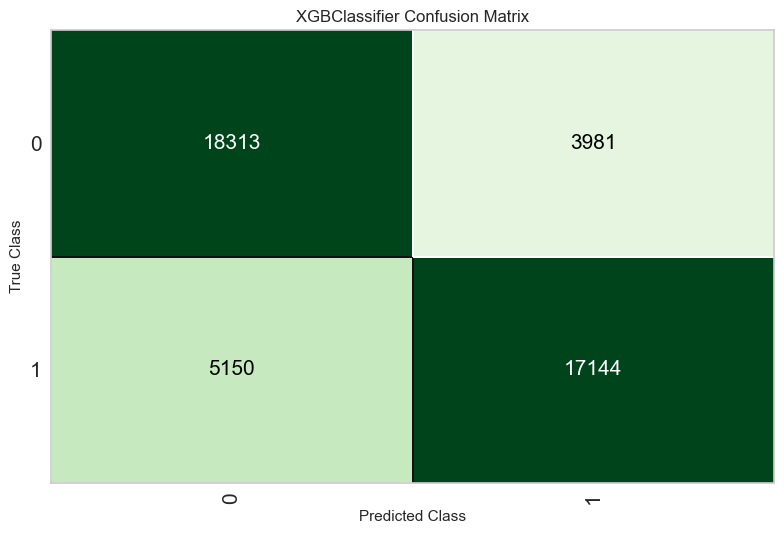

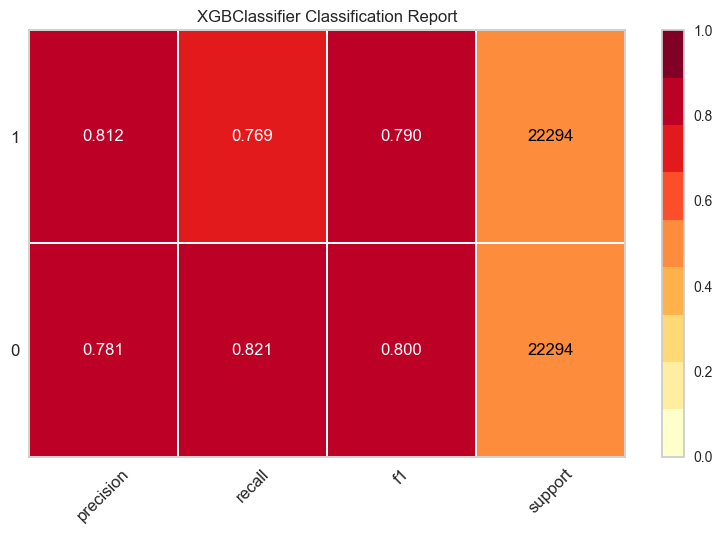

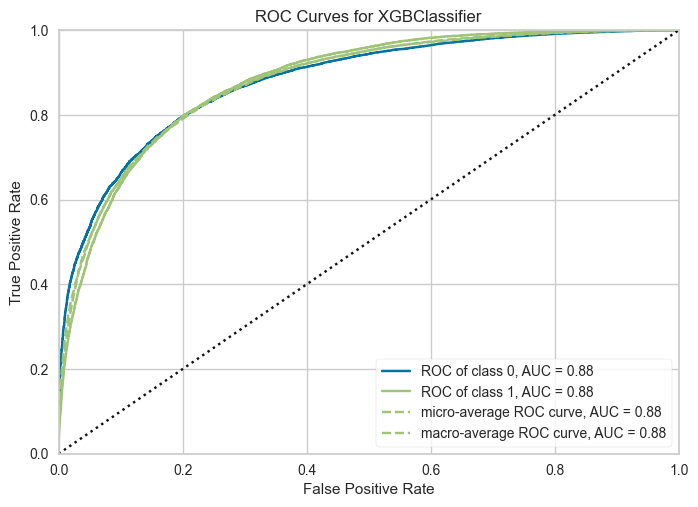

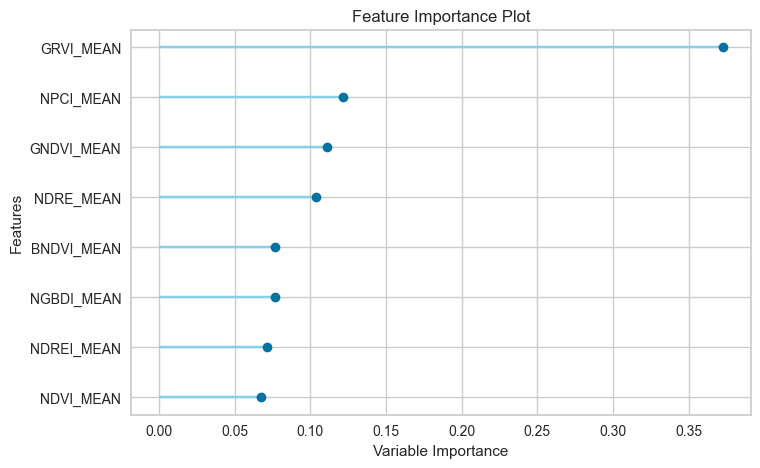

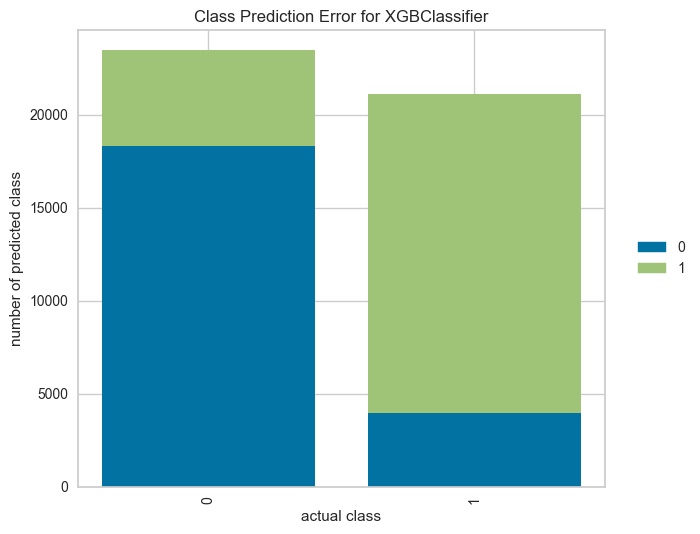

In [39]:
plot_model(xgboost_model_BL2_class, plot = 'confusion_matrix')
plot_model(xgboost_model_BL2_class, plot = 'class_report')
plot_model(xgboost_model_BL2_class, plot = 'auc')
plot_model(xgboost_model_BL2_class, plot = 'feature')
plot_model(xgboost_model_BL2_class, plot = 'error')

#### Learning Curve

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pycaret.classification import (
    setup, create_model, pull, get_config, set_config
    # use pycaret.regression if it's a regression problem
)

def pycaret_learning_curve(
    data: pd.DataFrame,
    target: str,
    model_name: str = "rf",
    train_sizes=np.linspace(0.1, 1.0, 10),
    metric: str = "AUC",   # change to e.g. "Accuracy", "F1", "RMSE", etc.
    fold: int = 5,
    seed: int = 8337,
):
    # 1) Full setup once (so preprocessing is fixed)
    setup(
        data=data,
        target=target,
        session_id=seed,
        fold=fold,
        normalize = True,
        remove_outliers = False
    )

    # Grab PyCaret's current train/test split & preprocessing context
    X_train = get_config("X_train").copy()
    y_train = get_config("y_train").copy()

    n = len(X_train)
    sizes = (train_sizes * n).astype(int)
    sizes = np.clip(sizes, 2, n)  # avoid tiny sizes
    sizes = np.unique(sizes)

    train_scores = []
    cv_scores = []

    # 2) Train repeatedly on increasing subsets
    for s in sizes:
        X_sub = X_train.iloc[:s]
        y_sub = y_train.iloc[:s]

        # Temporarily override PyCaret configs so create_model uses the subset
        old_X_train, old_y_train = get_config("X_train"), get_config("y_train")
        set_config("X_train", X_sub)
        set_config("y_train", y_sub)

        _ = create_model(model_name, fold=fold, verbose=False)
        results = pull()  # CV table for this run

        # Typical PyCaret CV table has rows Fold 0..k-1 plus Mean/Std
        mean_row = results.iloc[-2] if "Mean" in str(results.iloc[-2, 0]) else results.iloc[-1]
        cv_score = float(mean_row[metric]) if metric in mean_row else float(results[metric].iloc[-1])

        # Train score isn't always in pull(); simplest is track CV only.
        cv_scores.append(cv_score)
        train_scores.append(np.nan)

        # Restore
        set_config("X_train", old_X_train)
        set_config("y_train", old_y_train)

    # 3) Plot
    plt.figure()
    plt.plot(sizes, cv_scores, marker="o")
    plt.xlabel("Training set size (rows)")
    plt.ylabel(metric)
    plt.title(f"Learning Curve (PyCaret {model_name})")
    plt.grid(True)
    plt.show()

    return pd.DataFrame({"train_size": sizes, "cv_score": cv_scores})

# Example:
df_scores = pycaret_learning_curve(data=df_train_oversampling_BL2_class, target="BL", model_name="xgboost", metric="AUC", fold=5)

,Description,Value
0,Session id,8337
1,Target,BL
2,Target type,Binary
3,Target mapping,"1: 0, 2: 1"
4,Original data shape,"(148626, 9)"
5,Transformed data shape,"(148626, 9)"
6,Transformed train set shape,"(104038, 9)"
7,Transformed test set shape,"(44588, 9)"
8,Numeric features,8
9,Preprocess,True


ValueError: Variable X_train not found or is not writeable. Possible writeable variables are: ['fold_generator', 'gpu_param', 'fix_imbalance', 'exp_id', 'fold_shuffle_param', 'n_jobs_param', 'html_param', 'fold_groups_param', 'idx', 'USI', 'seed', 'exp_name_log', 'data', 'target_param', 'memory', 'logging_param', 'pipeline', 'log_plots_param']

#### Test Data

##### Predict Model

In [187]:
y_pred = predict_model(xgboost_model_BL2_class, data=df_test_BL2_class)
y_pred

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Extreme Gradient Boosting,0.7976,0.7942,0.7976,0.8640,0.8217,0.3281,0.3524


,NDRE_MEAN,NDVI_MEAN,GNDVI_MEAN,BNDVI_MEAN,NDREI_MEAN,NPCI_MEAN,GRVI_MEAN,NGBDI_MEAN,BL,prediction_label,prediction_score
4000,0.005446,0.522626,0.177353,0.264986,0.528796,0.263231,0.404285,0.094712,2,2,0.8065
102486,0.433159,0.884795,0.699309,0.885197,0.746135,0.740169,0.509838,0.496381,1,1,0.8245
5734,0.013409,0.219779,0.097902,-0.003010,0.208317,-0.016333,0.126730,-0.101556,2,2,0.8877
71869,0.569783,0.917069,0.797346,0.911170,0.738118,0.714489,0.460960,0.419079,1,2,0.5436
31160,0.210662,0.795868,0.628320,0.727977,0.708636,0.613824,0.348614,0.181989,2,2,0.5395
...,...,...,...,...,...,...,...,...,...,...,...
51867,0.298042,0.875633,0.729530,0.790164,0.786883,0.645619,0.419582,0.137726,1,1,0.7766
11022,0.048709,0.309092,0.165626,0.080307,0.272269,0.032562,0.157798,-0.090473,2,2,0.8249
31572,0.153541,0.693194,0.518969,0.624935,0.606542,0.522445,0.278595,0.156833,1,1,0.5959
705,-0.075319,0.195860,-0.055063,0.018076,0.270112,0.093395,0.257105,0.074646,2,2,0.8516


##### Confusion Matrix

              precision    recall  f1-score   support

           1       0.94      0.82      0.88     31819
           2       0.34      0.63      0.44      4547

    accuracy                           0.80     36366
   macro avg       0.64      0.73      0.66     36366
weighted avg       0.86      0.80      0.82     36366



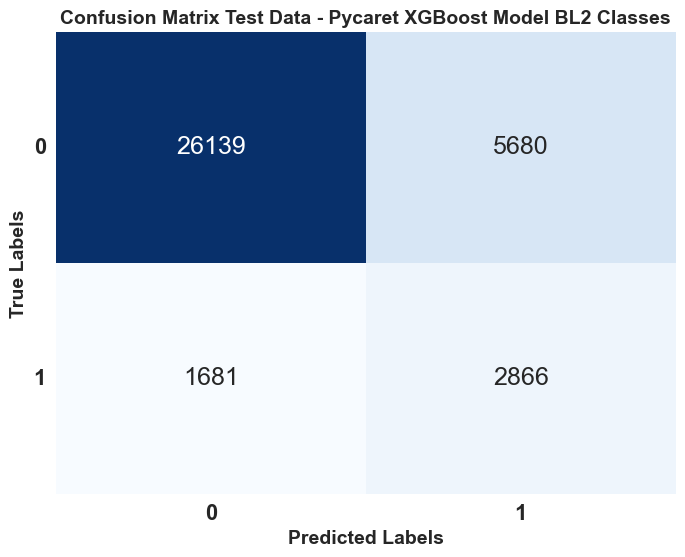

In [188]:
# Extraer las etiquetas verdaderas y las predicciones
y_true = df_test_BL2_class['BL']  # Etiquetas verdaderas
y_true = y_true.astype(int)

y_predicted = y_pred['prediction_label']  # Predicciones

# Generar la matriz de confusión
conf_matrix = confusion_matrix(y_true, y_predicted)

# Generar el reporte de clasificación (opcional)
print(classification_report(y_true, y_predicted))

# Visualizar la matriz de confusión usando seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False, annot_kws={"size": 18})
plt.title('Confusion Matrix Test Data - Pycaret XGBoost Model BL2 Classes', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Labels', fontsize=14, fontweight='bold')
plt.ylabel('True Labels', fontsize=14, fontweight='bold')
plt.xticks(rotation=0, fontsize=16, fontweight='bold')
plt.yticks(rotation=0, fontsize=16, fontweight='bold')
plt.show()

##### Classification Report

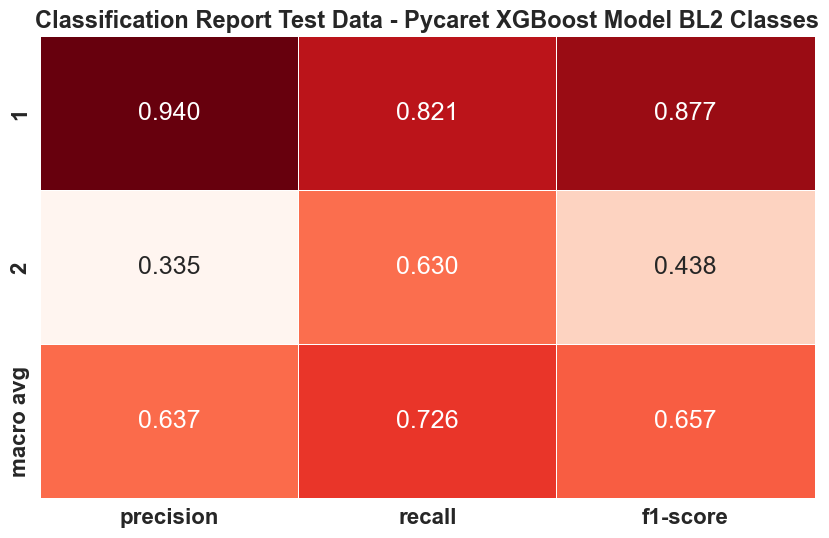

In [189]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report
import pandas as pd

# Generar el reporte de clasificación en formato de diccionario
report = classification_report(y_true, y_predicted, output_dict=True)

# Convertir el reporte a un DataFrame
df_report = pd.DataFrame(report).transpose()

# Eliminar filas no deseadas si existen en el reporte
df_report = df_report.drop(['accuracy', 'weighted avg'], axis=0, errors='ignore')

# Redondear las métricas a tres decimales
df_report = df_report.round(3)

# Visualización del reporte de clasificación en un heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df_report[['precision', 'recall', 'f1-score']], annot=True, cmap="Reds", fmt='.3f', linewidths=0.5, cbar=False, annot_kws={"size": 18})

# Ajustes visuales
plt.title('Classification Report Test Data - Pycaret XGBoost Model BL2 Classes', fontsize=17, fontweight='bold')
plt.yticks(fontsize=16, fontweight='bold') 
plt.xticks(fontsize=16, fontweight='bold') 
plt.show()

#### Test Data 2025

##### Predict Model

In [190]:
y_pred = predict_model(xgboost_model_BL2_class, data=df_blast_2025_BL2_class)
y_pred

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Extreme Gradient Boosting,0.7455,0.8009,0.7455,0.7403,0.7423,0.3939,0.3946


,NDRE_MEAN,NDVI_MEAN,GNDVI_MEAN,BNDVI_MEAN,NDREI_MEAN,NPCI_MEAN,GRVI_MEAN,NGBDI_MEAN,BL,prediction_label,prediction_score
0,0.402884,0.645484,0.496940,0.584175,0.350823,0.248622,0.242076,0.131727,1,1,0.8864
1,0.338142,0.605546,0.421575,0.521311,0.354174,0.232160,0.266874,0.136433,1,1,0.9643
2,0.360965,0.608588,0.454774,0.555703,0.331901,0.251866,0.226746,0.141117,1,1,0.7624
3,0.390195,0.624568,0.487076,0.565432,0.333183,0.237119,0.221060,0.117145,1,1,0.5792
4,0.352106,0.586691,0.424047,0.510977,0.315157,0.204158,0.234361,0.117674,1,1,0.5351
...,...,...,...,...,...,...,...,...,...,...,...
28144,0.047516,0.548904,0.366665,0.402583,0.531388,0.371160,0.230832,0.035626,1,2,0.7287
28145,0.165198,0.591586,0.432301,0.529140,0.495980,0.413385,0.227321,0.126510,1,2,0.5725
28146,0.092038,0.629184,0.414276,0.530805,0.587353,0.471379,0.294637,0.142926,1,1,0.7250
28147,0.133821,0.622384,0.439951,0.534815,0.552204,0.443288,0.258793,0.119393,1,2,0.5843


##### Confusion Matrix

              precision    recall  f1-score   support

           1       0.80      0.83      0.82     19356
           2       0.60      0.55      0.58      8793

    accuracy                           0.75     28149
   macro avg       0.70      0.69      0.70     28149
weighted avg       0.74      0.75      0.74     28149



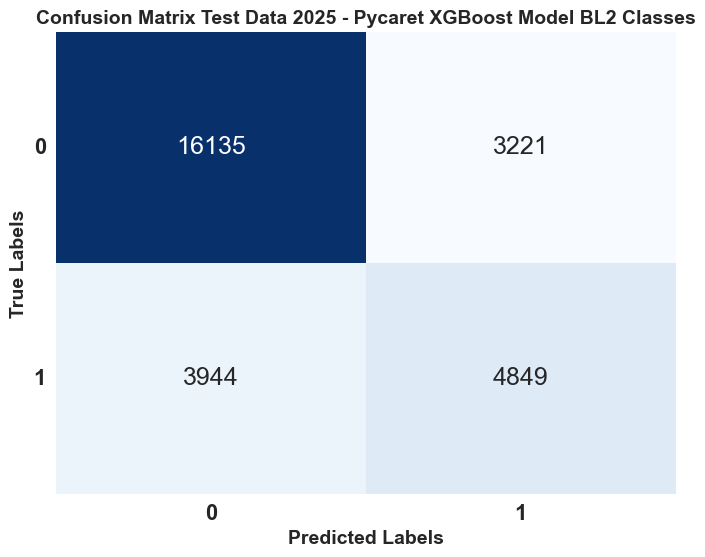

In [191]:
# Extraer las etiquetas verdaderas y las predicciones
y_true = df_blast_2025_BL2_class['BL']  # Etiquetas verdaderas
y_true = y_true.astype(int)

y_predicted = y_pred['prediction_label']  # Predicciones

# Generar la matriz de confusión
conf_matrix = confusion_matrix(y_true, y_predicted)

# Generar el reporte de clasificación (opcional)
print(classification_report(y_true, y_predicted))

# Visualizar la matriz de confusión usando seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False, annot_kws={"size": 18})
plt.title('Confusion Matrix Test Data 2025 - Pycaret XGBoost Model BL2 Classes', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Labels', fontsize=14, fontweight='bold')
plt.ylabel('True Labels', fontsize=14, fontweight='bold')
plt.xticks(rotation=0, fontsize=16, fontweight='bold')
plt.yticks(rotation=0, fontsize=16, fontweight='bold')
plt.show()

##### Classification Report

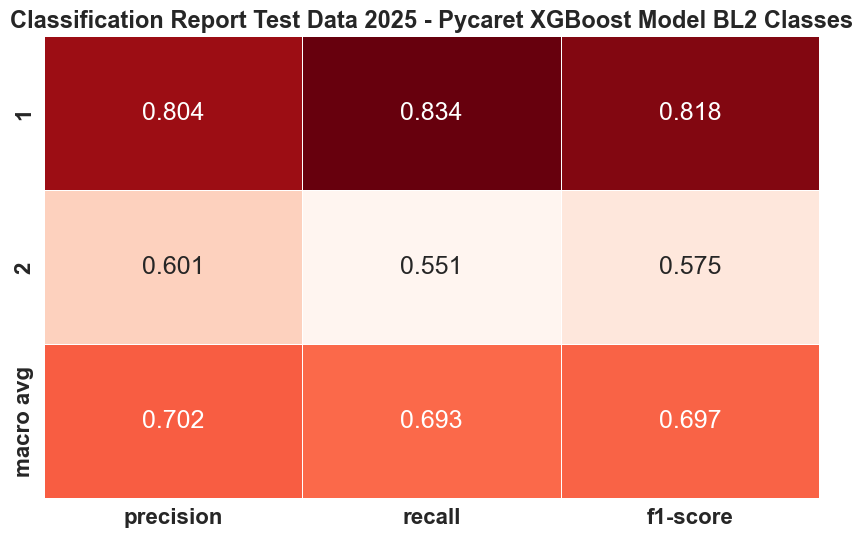

In [192]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report
import pandas as pd

# Generar el reporte de clasificación en formato de diccionario
report = classification_report(y_true, y_predicted, output_dict=True)

# Convertir el reporte a un DataFrame
df_report = pd.DataFrame(report).transpose()

# Eliminar filas no deseadas si existen en el reporte
df_report = df_report.drop(['accuracy', 'weighted avg'], axis=0, errors='ignore')

# Redondear las métricas a tres decimales
df_report = df_report.round(3)

# Visualización del reporte de clasificación en un heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df_report[['precision', 'recall', 'f1-score']], annot=True, cmap="Reds", fmt='.3f', linewidths=0.5, cbar=False, annot_kws={"size": 18})

# Ajustes visuales
plt.title('Classification Report Test Data 2025 - Pycaret XGBoost Model BL2 Classes', fontsize=17, fontweight='bold')
plt.yticks(fontsize=16, fontweight='bold')  # Etiquetas de clase en vertical
plt.xticks(fontsize=16, fontweight='bold')  # Rotación de etiquetas en el eje X
plt.show()

### 3 Classes

#### Train & Test Data

In [193]:
from sklearn.model_selection import train_test_split

# Supongamos que `df` es tu DataFrame completo
df_train_BL3_class, df_test_BL3_class = train_test_split(df_blast_2022_2023_2024_BL3_class, test_size=0.3, random_state=24)

print(f"Tamaño del conjunto de entrenamiento BL3_class: {len(df_train_BL3_class)}")
print(f"Tamaño del conjunto de prueba BL3_class: {len(df_test_BL3_class)}")

BL_counts = df_train_BL3_class['BL'].value_counts()
print("df_train_BL3_class",BL_counts)

BL_counts = df_test_BL3_class['BL'].value_counts()
print("df_test_BL3_class", BL_counts)

Tamaño del conjunto de entrenamiento BL3_class: 84851
Tamaño del conjunto de prueba BL3_class: 36366
df_train_BL3_class BL
1    67376
2    12324
3     5151
Name: count, dtype: int64
df_test_BL3_class BL
1    28901
2     5258
3     2207
Name: count, dtype: int64


#### Train Data Oversampling

In [194]:
df_train_oversampling_BL3_class = balance_dataset_oversampling(df_train_BL3_class, target_column='BL', oversampling_factor=1)

Distribución antes del oversampling:
 BL
1    67376
2    12324
3     5151
Name: count, dtype: int64
Distribución después del oversampling:
 BL
1    67376
3    67376
2    67376
Name: count, dtype: int64


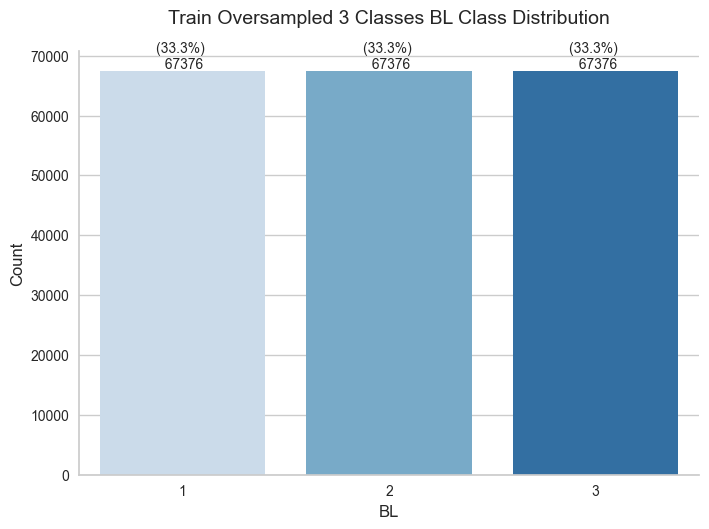

BL
3    67376
1    67376
2    67376
Name: count, dtype: int64


In [195]:
plot_class_distribution(df_train_oversampling_BL3_class, dataset_name = "Train Oversampled 3 Classes BL", column ="BL")
BL_counts = df_train_oversampling_BL3_class['BL'].value_counts()
print(BL_counts)

#### Setup Model

In [196]:
model_blast_BL3_class = setup(data = df_train_oversampling_BL3_class,
                target ='BL',
                normalize = True, # Estaba en True
                remove_outliers = False,
                session_id= 8337,
                )

,Description,Value
0,Session id,8337
1,Target,BL
2,Target type,Multiclass
3,Target mapping,"1: 0, 2: 1, 3: 2"
4,Original data shape,"(202128, 9)"
5,Transformed data shape,"(202128, 9)"
6,Transformed train set shape,"(141489, 9)"
7,Transformed test set shape,"(60639, 9)"
8,Numeric features,8
9,Preprocess,True


#### Compare Models

In [50]:
models_BL3_class = compare_models(include=['et', 'rf', 'dt', 'knn', 'xgboost', 'lightgbm'])
df_models_BL3_class = pull()

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
et,Extra Trees Classifier,0.9702,0.9969,0.9702,0.9703,0.9700,0.9553,0.9555,3.2540
rf,Random Forest Classifier,0.9525,0.9959,0.9525,0.9541,0.9520,0.9288,0.9300,9.7380
dt,Decision Tree Classifier,0.9167,0.9375,0.9167,0.9240,0.9145,0.8750,0.8803,1.0940
knn,K Neighbors Classifier,0.8099,0.9266,0.8099,0.8132,0.8026,0.7149,0.7221,0.7640
xgboost,Extreme Gradient Boosting,0.6864,0.8623,0.6864,0.6846,0.6821,0.5295,0.5322,1.0950
lightgbm,Light Gradient Boosting Machine,0.6254,0.8167,0.6254,0.6243,0.6162,0.4380,0.4443,1.7430


In [51]:
et_model_BL3_class = create_model('et')
rf_model_BL3_class = create_model('rf')
dt_model_BL3_class = create_model('dt')
knn_model_BL3_class = create_model('knn')
xgboost_model_BL3_class = create_model('xgboost')
lightgbm_model_BL3_class = create_model('lightgbm')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9702,0.9963,0.9702,0.9703,0.9701,0.9553,0.9554
1,0.9690,0.9966,0.9690,0.9691,0.9689,0.9536,0.9537
2,0.9713,0.9970,0.9713,0.9714,0.9712,0.9570,0.9571
3,0.9701,0.9970,0.9701,0.9703,0.9700,0.9552,0.9554
4,0.9701,0.9973,0.9701,0.9703,0.9700,0.9552,0.9554
5,0.9703,0.9975,0.9703,0.9706,0.9702,0.9555,0.9558
6,0.9710,0.9966,0.9710,0.9711,0.9708,0.9564,0.9566
7,0.9699,0.9971,0.9699,0.9702,0.9698,0.9548,0.9551
8,0.9709,0.9969,0.9709,0.9710,0.9707,0.9563,0.9565


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9530,0.9956,0.9530,0.9545,0.9526,0.9295,0.9306
1,0.9517,0.9958,0.9517,0.9533,0.9512,0.9275,0.9287
2,0.9539,0.9961,0.9539,0.9554,0.9535,0.9309,0.9320
3,0.9522,0.9960,0.9522,0.9539,0.9517,0.9283,0.9296
4,0.9534,0.9965,0.9534,0.9551,0.9529,0.9300,0.9313
5,0.9511,0.9963,0.9511,0.9531,0.9505,0.9266,0.9281
6,0.9538,0.9958,0.9538,0.9553,0.9534,0.9308,0.9319
7,0.9506,0.9961,0.9506,0.9527,0.9501,0.9259,0.9274
8,0.9524,0.9959,0.9524,0.9541,0.9519,0.9287,0.9299


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9152,0.9364,0.9152,0.9224,0.9129,0.8728,0.8781
1,0.9181,0.9386,0.9181,0.9246,0.9161,0.8771,0.8819
2,0.9165,0.9374,0.9165,0.9246,0.9143,0.8748,0.8804
3,0.9136,0.9352,0.9136,0.9216,0.9111,0.8703,0.8761
4,0.9186,0.9389,0.9186,0.9259,0.9165,0.8779,0.8830
5,0.9162,0.9372,0.9162,0.9241,0.9140,0.8744,0.8799
6,0.9158,0.9368,0.9158,0.9231,0.9135,0.8736,0.8790
7,0.9162,0.9371,0.9162,0.9233,0.9139,0.8743,0.8795
8,0.9167,0.9375,0.9167,0.9241,0.9144,0.8750,0.8804


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.8019,0.9264,0.8019,0.8039,0.7943,0.7028,0.7098
1,0.8078,0.9246,0.8078,0.8111,0.8003,0.7117,0.7192
2,0.8128,0.9275,0.8128,0.8157,0.8060,0.7193,0.7261
3,0.8083,0.9264,0.8083,0.8122,0.8007,0.7125,0.7203
4,0.8129,0.9270,0.8129,0.8161,0.8057,0.7194,0.7266
5,0.8043,0.9239,0.8043,0.8092,0.7962,0.7064,0.7148
6,0.8104,0.9253,0.8104,0.8135,0.8034,0.7157,0.7227
7,0.8153,0.9289,0.8153,0.8196,0.8086,0.7230,0.7302
8,0.8128,0.9281,0.8128,0.8150,0.8060,0.7193,0.7257


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.6885,0.8639,0.6885,0.6867,0.6839,0.5327,0.5355
1,0.6908,0.8656,0.6908,0.6885,0.6863,0.5362,0.5387
2,0.6838,0.8633,0.6838,0.6817,0.6793,0.5257,0.5284
3,0.6901,0.8624,0.6901,0.6890,0.6858,0.5351,0.5380
4,0.6885,0.8636,0.6885,0.6875,0.6844,0.5328,0.5356
5,0.6820,0.8565,0.6820,0.6793,0.6775,0.5230,0.5255
6,0.6817,0.8617,0.6817,0.6795,0.6777,0.5225,0.5248
7,0.6893,0.8633,0.6893,0.6875,0.6858,0.5340,0.5360
8,0.6842,0.8621,0.6842,0.6826,0.6796,0.5263,0.5293


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.6234,0.8181,0.6234,0.6225,0.6136,0.4352,0.4419
1,0.6280,0.8186,0.6280,0.6266,0.6188,0.4421,0.4482
2,0.6251,0.8175,0.6251,0.6239,0.6162,0.4377,0.4436
3,0.6256,0.8158,0.6256,0.6253,0.6162,0.4384,0.4451
4,0.6345,0.8210,0.6345,0.6335,0.6257,0.4517,0.4577
5,0.6203,0.8126,0.6203,0.6179,0.6104,0.4305,0.4366
6,0.6243,0.8180,0.6243,0.6233,0.6147,0.4364,0.4430
7,0.6260,0.8170,0.6260,0.6250,0.6172,0.4390,0.4450
8,0.6232,0.8154,0.6232,0.6224,0.6136,0.4347,0.4414


#### Models Parameters

In [52]:
params_map = {
    "rf": estimate_param_count(rf_model_BL3_class),
    "et": estimate_param_count(et_model_BL3_class),
    "dt": estimate_param_count(dt_model_BL3_class),
    "knn": estimate_param_count(knn_model_BL3_class),
    "xgboost": estimate_param_count(xgboost_model_BL3_class),
    "lightgbm": estimate_param_count(lightgbm_model_BL3_class),
}

In [53]:
results_df = df_models_BL3_class.copy()

# In PyCaret, the index is usually model names; sometimes the "Model" column exists.
# This makes it robust:
if "Model" in results_df.columns:
    key_series = results_df["Model"].astype(str).str.lower()
else:
    key_series = results_df.index.astype(str).str.lower()

# Map based on keywords in the name
def match_params(name):
    if "random forest" in name or name == "rf":
        return params_map["rf"]
    if "extra trees" in name or "extremely randomized" in name or name == "et":
        return params_map["et"]
    if "decision tree" in name or name == "dt":
        return params_map["dt"]
    if "knn" in name or "k neighbors" in name or "nearest neighbors" in name:
        return params_map["knn"]
    if "xgboost" in name or "extreme gradient boosting" in name or "xgb" in name:
        return params_map["xgboost"]
    if "lightgbm" in name or "light gradient boosting" in name or "lgbm" in name:
        return params_map["lightgbm"]
    return None

results_df["Params"] = key_series.map(match_params)

# If any are missing, show them:
missing = results_df[results_df["Params"].isna()]
if len(missing) > 0:
    print("Rows missing Params mapping:\n", missing.index if "Model" not in missing.columns else missing["Model"])


In [54]:
complexity_map = {
    "Random Forest Classifier": model_complexity(rf_model_BL3_class),
    "Extra Trees Classifier": model_complexity(et_model_BL3_class),
    "Decision Tree Classifier": model_complexity(dt_model_BL3_class),
    "K Neighbors Classifier": model_complexity(knn_model_BL3_class),
    "Extreme Gradient Boosting": model_complexity(xgboost_model_BL3_class),
    "Light Gradient Boosting Machine": model_complexity(lightgbm_model_BL3_class),
}

results_df["Complexity"] = results_df["Model"].map(complexity_map)

In [55]:
results_df

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec),Params,Complexity
et,Extra Trees Classifier,0.9702,0.9969,0.9702,0.9703,0.9700,0.9553,0.9555,3.254,6517054,6517054
rf,Random Forest Classifier,0.9525,0.9959,0.9525,0.9541,0.9520,0.9288,0.9300,9.738,3085808,3085808
dt,Decision Tree Classifier,0.9167,0.9375,0.9167,0.9240,0.9145,0.8750,0.8803,1.094,29427,29427
knn,K Neighbors Classifier,0.8099,0.9266,0.8099,0.8132,0.8026,0.7149,0.7221,0.764,8,8
xgboost,Extreme Gradient Boosting,0.6864,0.8623,0.6864,0.6846,0.6821,0.5295,0.5322,1.095,11,28216
lightgbm,Light Gradient Boosting Machine,0.6254,0.8167,0.6254,0.6243,0.6162,0.4380,0.4443,1.743,8,9300


In [56]:
print("XGB:", xgb_complexity(xgboost_model_BL3_class))
print("LGBM:", lgbm_complexity(lightgbm_model_BL3_class))

XGB: {'xgb_n_trees': 300, 'xgb_total_nodes': 28216, 'xgb_total_leaves': 14258, 'complexity': 28216}
LGBM: {'lgbm_n_trees': 300, 'lgbm_total_leaves': 9300, 'lgbm_total_nodes_approx': 9000, 'complexity': 9300}


##### Training Time vs Accuracy

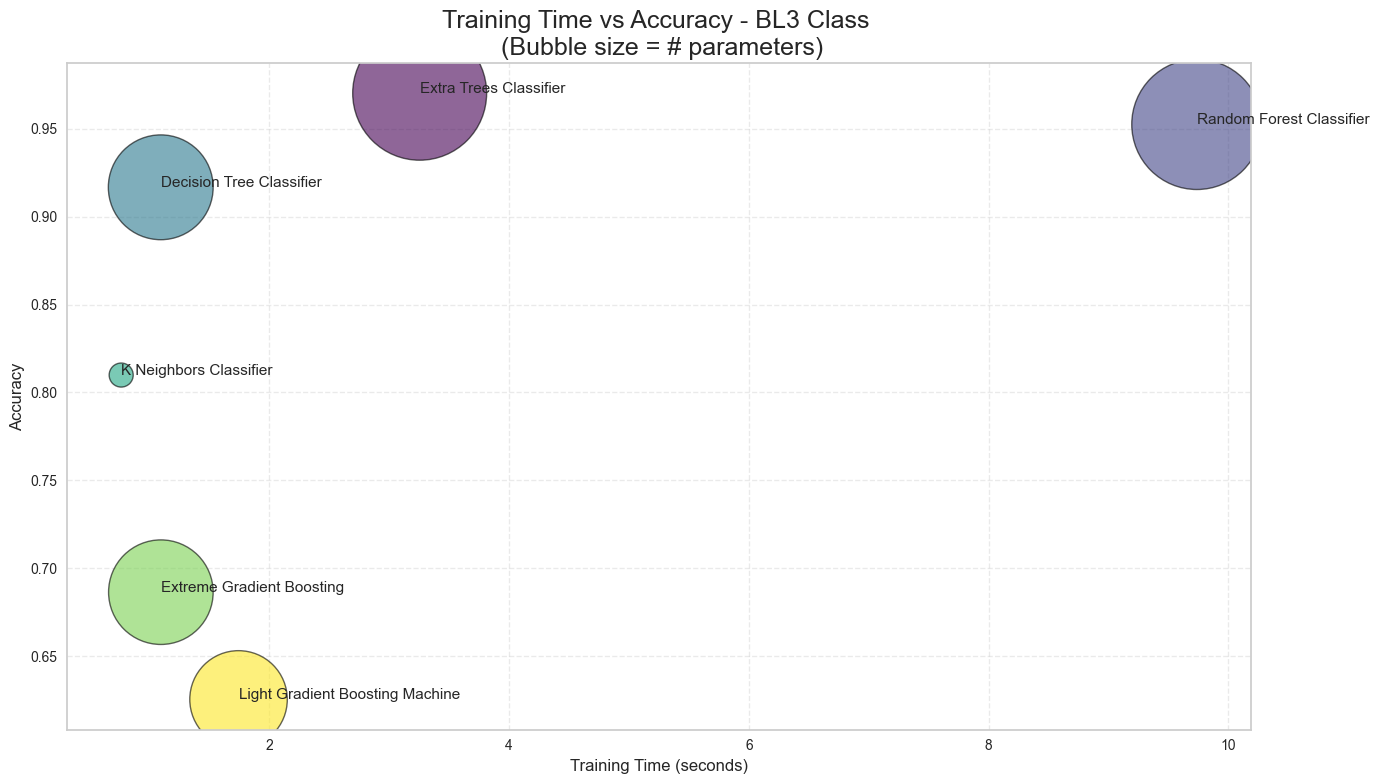

In [57]:
import matplotlib.pyplot as plt
import numpy as np

df = results_df.dropna(subset=["Params"]).copy()

x = df["TT (Sec)"]
y = df["Accuracy"]
labels = df.index if "Model" not in df.columns else df["Model"]
#sizes = df["Params"]
#sizes = np.log1p(results_df["Complexity"].astype(float)) * 1500

# Bubble scaling — tune this ONE line if needed
#bubble_sizes = sizes / (sizes.max() / 8000)  # auto-scale to nice range
#bubble_sizes = np.log1p(sizes) * 2000

sizes = df["Complexity"].astype(float)
s = np.log1p(sizes)

bubble_sizes = 300 + (s - s.min()) / (s.max() - s.min() + 1e-9) * 9000

plt.figure(figsize=(14, 8))

colors = np.linspace(0, 1, len(df))
plt.scatter(
    x, y,
    s=bubble_sizes,
    c=colors,
    cmap="viridis",
    alpha=0.6,
    edgecolors="black",
    linewidths=1
)

for i in range(len(df)):
    plt.text(x.iloc[i], y.iloc[i], str(labels.iloc[i] if hasattr(labels, "iloc") else labels[i]), fontsize=11)

plt.title("Training Time vs Accuracy - BL3 Class \n (Bubble size = # parameters)", fontsize=18)
plt.xlabel("Training Time (seconds)", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


#### Create Model

In [197]:
xgboost_model_BL3_class = create_model('xgboost')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.6885,0.8639,0.6885,0.6867,0.6839,0.5327,0.5355
1,0.6908,0.8656,0.6908,0.6885,0.6863,0.5362,0.5387
2,0.6838,0.8633,0.6838,0.6817,0.6793,0.5257,0.5284
3,0.6901,0.8624,0.6901,0.6890,0.6858,0.5351,0.5380
4,0.6885,0.8636,0.6885,0.6875,0.6844,0.5328,0.5356
5,0.6820,0.8565,0.6820,0.6793,0.6775,0.5230,0.5255
6,0.6817,0.8617,0.6817,0.6795,0.6777,0.5225,0.5248
7,0.6893,0.8633,0.6893,0.6875,0.6858,0.5340,0.5360
8,0.6842,0.8621,0.6842,0.6826,0.6796,0.5263,0.5293


#### Analyze Model

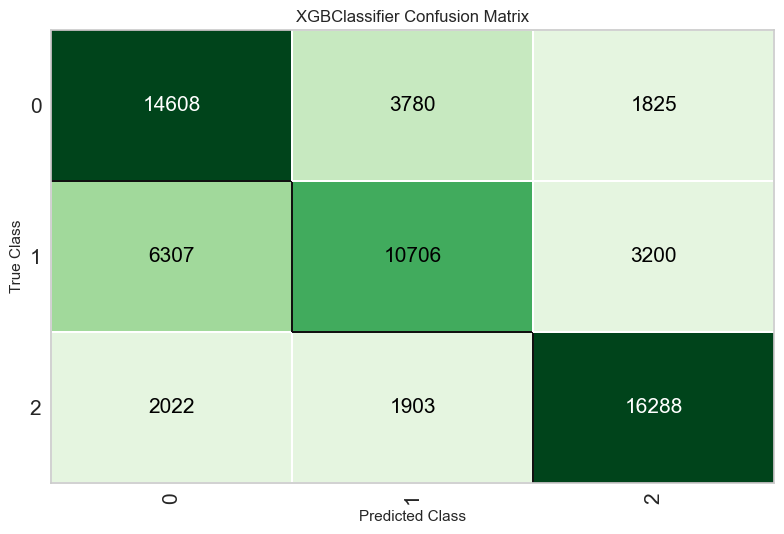

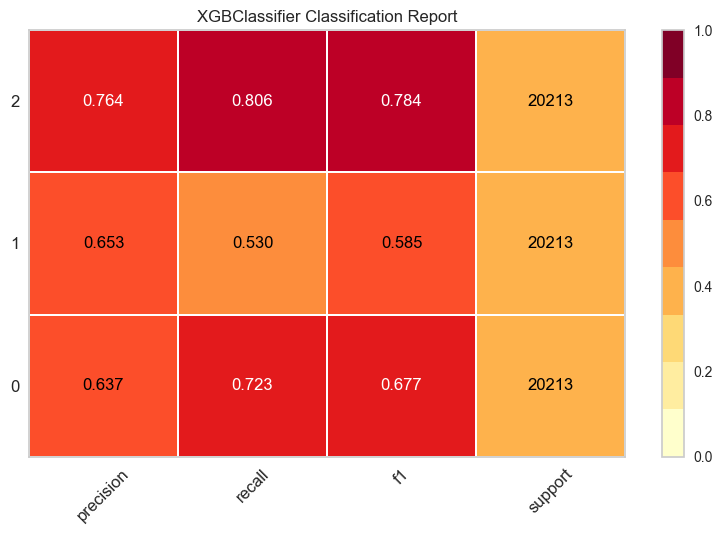

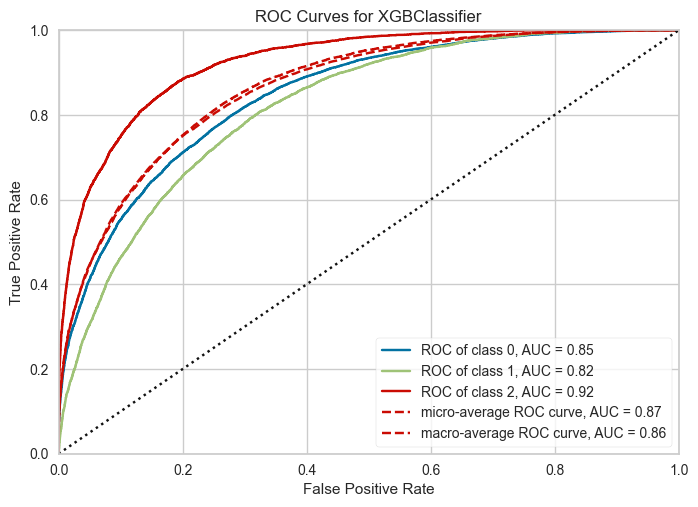

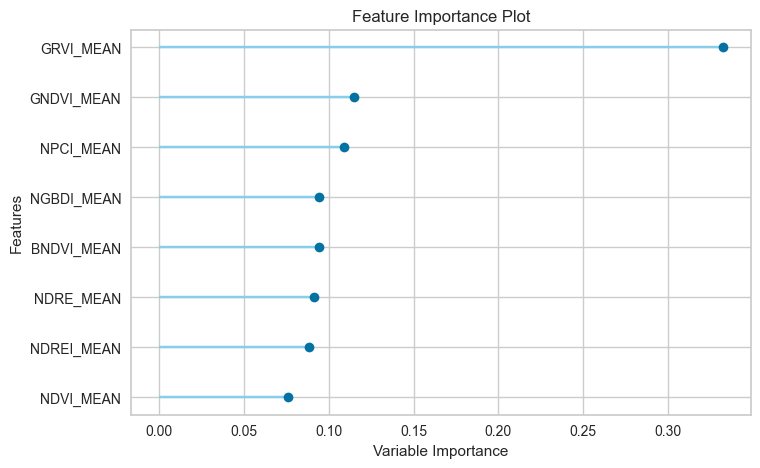

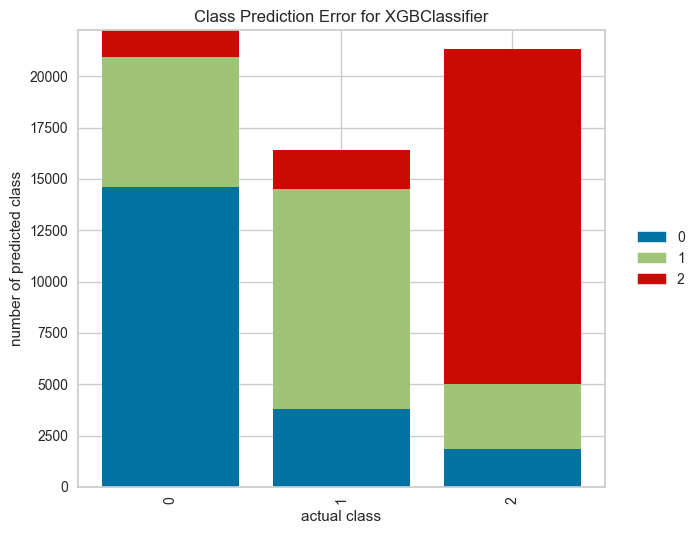

In [59]:
plot_model(xgboost_model_BL3_class, plot = 'confusion_matrix')
plot_model(xgboost_model_BL3_class, plot = 'class_report')
plot_model(xgboost_model_BL3_class, plot = 'auc')
plot_model(xgboost_model_BL3_class, plot = 'feature')
plot_model(xgboost_model_BL3_class, plot = 'error')

#### Test Data

##### Predict Model

In [198]:
y_pred = predict_model(xgboost_model_BL3_class, data=df_test_BL3_class)
y_pred

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Extreme Gradient Boosting,0.6627,0.7444,0.6627,0.7581,0.6974,0.2484,0.2637


,NDRE_MEAN,NDVI_MEAN,GNDVI_MEAN,BNDVI_MEAN,NDREI_MEAN,NPCI_MEAN,GRVI_MEAN,NGBDI_MEAN,BL,prediction_label,prediction_score
4000,0.005446,0.522626,0.177353,0.264986,0.528796,0.263231,0.404285,0.094712,2,2,0.5208
102486,0.433159,0.884795,0.699309,0.885197,0.746135,0.740169,0.509838,0.496381,1,1,0.8269
5734,0.013409,0.219779,0.097902,-0.003010,0.208317,-0.016333,0.126730,-0.101556,3,3,0.6052
71869,0.569783,0.917069,0.797346,0.911170,0.738118,0.714489,0.460960,0.419079,2,2,0.3943
31160,0.210662,0.795868,0.628320,0.727977,0.708636,0.613824,0.348614,0.181989,2,2,0.4681
...,...,...,...,...,...,...,...,...,...,...,...
51867,0.298042,0.875633,0.729530,0.790164,0.786883,0.645619,0.419582,0.137726,1,1,0.5086
11022,0.048709,0.309092,0.165626,0.080307,0.272269,0.032562,0.157798,-0.090473,3,2,0.5111
31572,0.153541,0.693194,0.518969,0.624935,0.606542,0.522445,0.278595,0.156833,1,1,0.5196
705,-0.075319,0.195860,-0.055063,0.018076,0.270112,0.093395,0.257105,0.074646,2,3,0.5259


##### Confusion Matrix

              precision    recall  f1-score   support

           1       0.89      0.72      0.80     28901
           2       0.24      0.36      0.29      5258
           3       0.27      0.63      0.37      2207

    accuracy                           0.66     36366
   macro avg       0.47      0.57      0.49     36366
weighted avg       0.76      0.66      0.70     36366



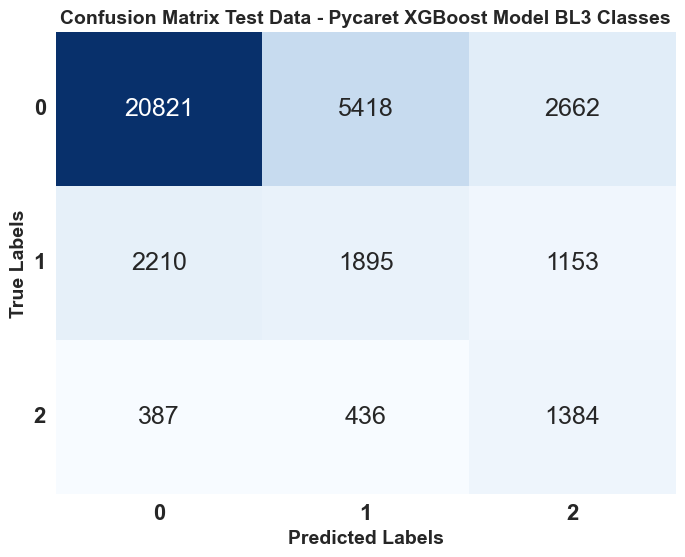

In [199]:
# Extraer las etiquetas verdaderas y las predicciones
y_true = df_test_BL3_class['BL']  # Etiquetas verdaderas
y_true = y_true.astype(int)

y_predicted = y_pred['prediction_label']  # Predicciones

# Generar la matriz de confusión
conf_matrix = confusion_matrix(y_true, y_predicted)

# Generar el reporte de clasificación (opcional)
print(classification_report(y_true, y_predicted))

# Visualizar la matriz de confusión usando seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False, annot_kws={"size": 18})
plt.title('Confusion Matrix Test Data - Pycaret XGBoost Model BL3 Classes', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Labels', fontsize=14, fontweight='bold')
plt.ylabel('True Labels', fontsize=14, fontweight='bold')
plt.xticks(rotation=0, fontsize=16, fontweight='bold')
plt.yticks(rotation=0, fontsize=16, fontweight='bold')
plt.show()

##### Classification Report

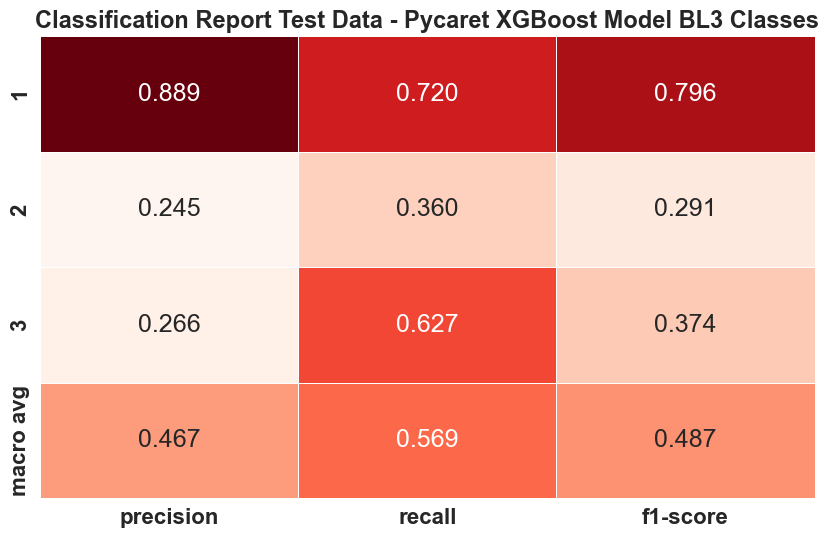

In [200]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report
import pandas as pd

# Generar el reporte de clasificación en formato de diccionario
report = classification_report(y_true, y_predicted, output_dict=True)

# Convertir el reporte a un DataFrame
df_report = pd.DataFrame(report).transpose()

# Eliminar filas no deseadas si existen en el reporte
df_report = df_report.drop(['accuracy', 'weighted avg'], axis=0, errors='ignore')

# Redondear las métricas a tres decimales
df_report = df_report.round(3)

# Visualización del reporte de clasificación en un heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df_report[['precision', 'recall', 'f1-score']], annot=True, cmap="Reds", fmt='.3f', linewidths=0.5, cbar=False, annot_kws={"size": 18})

# Ajustes visuales
plt.title('Classification Report Test Data - Pycaret XGBoost Model BL3 Classes', fontsize=17, fontweight='bold')
plt.yticks(fontsize=16, fontweight='bold')
plt.xticks(fontsize=16, fontweight='bold')
plt.show()

#### Test Data 2025

##### Predict Model

In [201]:
y_pred = predict_model(xgboost_model_BL3_class, data=df_blast_2025_BL3_class)
y_pred

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Extreme Gradient Boosting,0.4872,0.7313,0.4872,0.6368,0.5250,0.2526,0.2767


,NDRE_MEAN,NDVI_MEAN,GNDVI_MEAN,BNDVI_MEAN,NDREI_MEAN,NPCI_MEAN,GRVI_MEAN,NGBDI_MEAN,BL,prediction_label,prediction_score
0,0.402884,0.645484,0.496940,0.584175,0.350823,0.248622,0.242076,0.131727,1,1,0.4003
1,0.338142,0.605546,0.421575,0.521311,0.354174,0.232160,0.266874,0.136433,1,1,0.4303
2,0.360965,0.608588,0.454774,0.555703,0.331901,0.251866,0.226746,0.141117,1,2,0.3928
3,0.390195,0.624568,0.487076,0.565432,0.333183,0.237119,0.221060,0.117145,1,3,0.5266
4,0.352106,0.586691,0.424047,0.510977,0.315157,0.204158,0.234361,0.117674,1,3,0.4473
...,...,...,...,...,...,...,...,...,...,...,...
28144,0.047516,0.548904,0.366665,0.402583,0.531388,0.371160,0.230832,0.035626,1,3,0.5042
28145,0.165198,0.591586,0.432301,0.529140,0.495980,0.413385,0.227321,0.126510,1,3,0.4663
28146,0.092038,0.629184,0.414276,0.530805,0.587353,0.471379,0.294637,0.142926,1,1,0.4004
28147,0.133821,0.622384,0.439951,0.534815,0.552204,0.443288,0.258793,0.119393,1,3,0.4599


##### Confusion Matrix

              precision    recall  f1-score   support

           1       0.84      0.50      0.63     14250
           2       0.51      0.42      0.46     10275
           3       0.20      0.62      0.31      3624

    accuracy                           0.49     28149
   macro avg       0.52      0.52      0.46     28149
weighted avg       0.64      0.49      0.52     28149



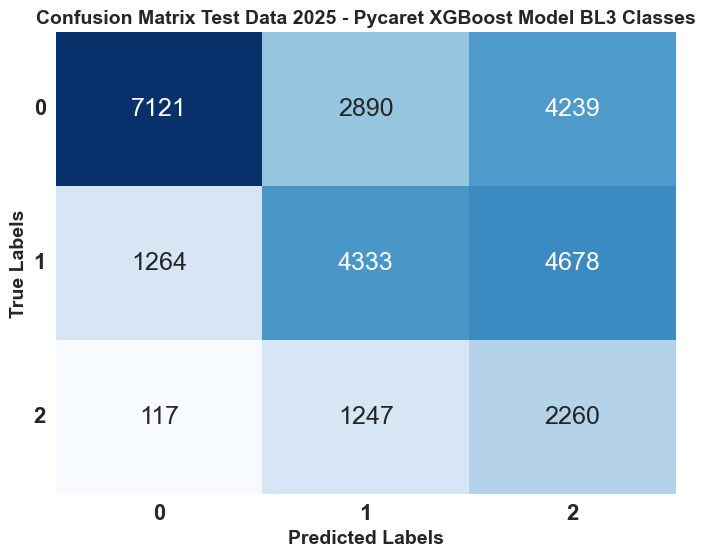

In [202]:
# Extraer las etiquetas verdaderas y las predicciones
y_true = df_blast_2025_BL3_class['BL']  # Etiquetas verdaderas
y_true = y_true.astype(int)

y_predicted = y_pred['prediction_label']  # Predicciones

# Generar la matriz de confusión
conf_matrix = confusion_matrix(y_true, y_predicted)

# Generar el reporte de clasificación (opcional)
print(classification_report(y_true, y_predicted))

# Visualizar la matriz de confusión usando seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False, annot_kws={"size": 18})
plt.title('Confusion Matrix Test Data 2025 - Pycaret XGBoost Model BL3 Classes', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Labels', fontsize=14, fontweight='bold')
plt.ylabel('True Labels', fontsize=14, fontweight='bold')
plt.xticks(rotation=0, fontsize=16, fontweight='bold')
plt.yticks(rotation=0, fontsize=16, fontweight='bold')
plt.show()

##### Classification Report

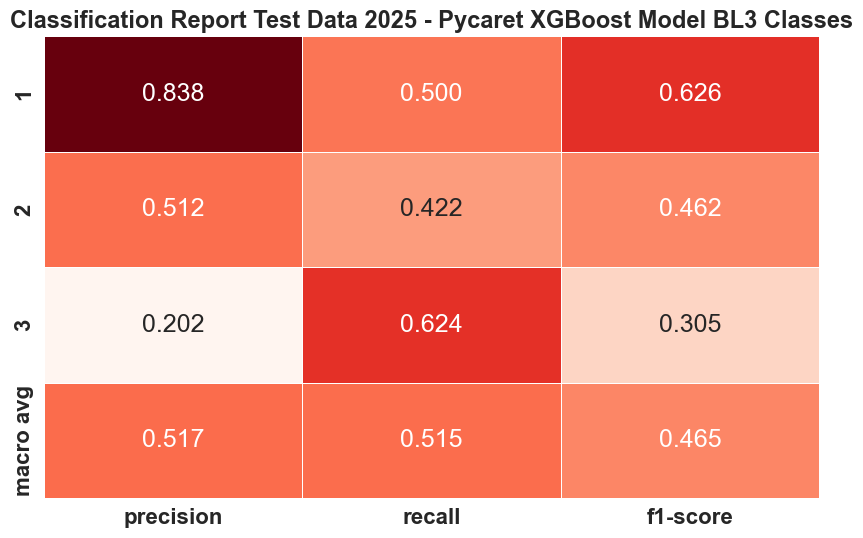

In [203]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report
import pandas as pd

# Generar el reporte de clasificación en formato de diccionario
report = classification_report(y_true, y_predicted, output_dict=True)

# Convertir el reporte a un DataFrame
df_report = pd.DataFrame(report).transpose()

# Eliminar filas no deseadas si existen en el reporte
df_report = df_report.drop(['accuracy', 'weighted avg'], axis=0, errors='ignore')

# Redondear las métricas a tres decimales
df_report = df_report.round(3)

# Visualización del reporte de clasificación en un heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df_report[['precision', 'recall', 'f1-score']], annot=True, cmap="Reds", fmt='.3f', linewidths=0.5, cbar=False, annot_kws={"size": 18})

# Ajustes visuales
plt.title('Classification Report Test Data 2025 - Pycaret XGBoost Model BL3 Classes', fontsize=17, fontweight='bold')
plt.yticks(fontsize=16, fontweight='bold')  # Etiquetas de clase en vertical
plt.xticks(fontsize=16, fontweight='bold')  # Rotación de etiquetas en el eje X
plt.show()

## XGBoost with Weighting

### 2 Classes

#### Train Data 

In [284]:
# Dividir el dataset en X_train_unb e y_train_unb
X_train_unb = df_train_BL2_class.drop(columns=['BL'])  # Todas las columnas excepto 'BL'
y_train_unb = df_train_BL2_class['BL']  # Solo la columna 'BL'
y_train_unb = y_train_unb.astype(float)  # Si tiene valores como strings de números (e.g., '1.0', '2.0')

# Convertir a entero
y_train_unb = y_train_unb.astype(int)
y_train_unb = y_train_unb - 1

# Verificar las dimensiones
print("Shape de X_train_unb:", X_train_unb.shape)
print("Shape de y_train_unb:", y_train_unb.shape)

Shape de X_train_unb: (84851, 8)
Shape de y_train_unb: (84851,)


In [285]:
y_train_unb.unique()

array([0, 1])

#### Create Model

In [286]:
# Calcular el ratio para scale_pos_weight
# scale_pos_weight = número de instancias negativas / número de instancias positivas
neg_count = (y_train_unb == 0).sum()
pos_count = (y_train_unb == 1).sum()
scale_pos_weight = neg_count / pos_count

# Crear el modelo de XGBoost 2 clases

model_BL2_class = xgb.XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    objective='binary:logistic',
    eval_metric='auc',  # Otras opciones: 'auc', 'error'
    use_label_encoder=False,
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)


# Crear el modelo de XGBoost 3 clases
"""
model_BL3_class = xgb.XGBClassifier(
    objective='multi:softprob',  # Clasificación multiclase con probabilidades
    num_class=3,                 # Especificar el número de clases
    eval_metric='mlogloss',      # Métrica para multiclase (log loss)
    use_label_encoder=False,
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)
"""

# Entrenar el modelo
model_BL2_class.fit(X_train_unb, y_train_unb)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='auc', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)

#### Learning Curve 

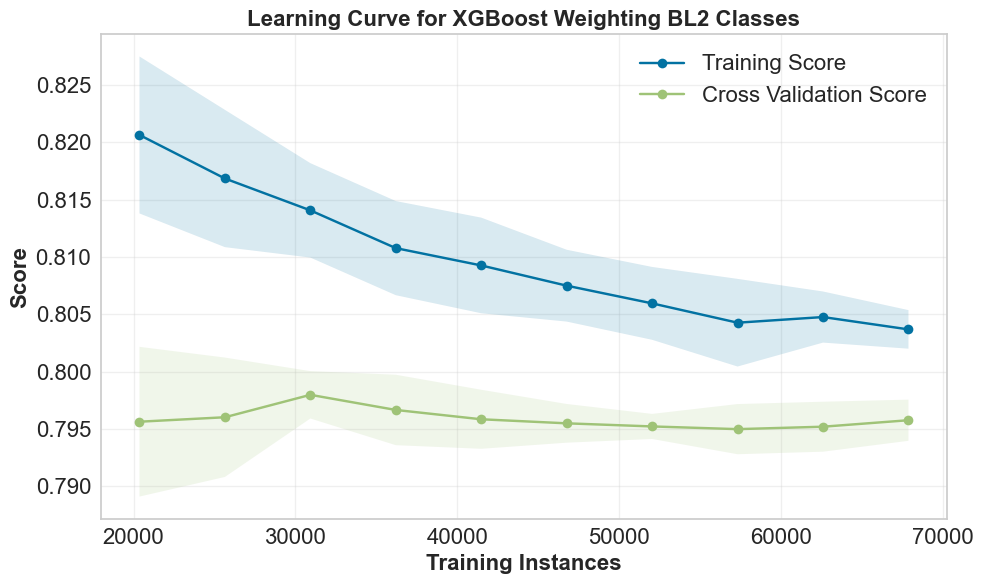

In [287]:
# --- Learning curve computation ---
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Choose scoring:
# - If your plot is accuracy-like, use scoring="accuracy"
# - If you want AUC (matches eval_metric='auc'), use scoring="roc_auc"
train_sizes = np.linspace(0.3, 1.0, 10)

sizes, train_scores, val_scores = learning_curve(
    estimator=model_BL2_class,
    X=X_train_unb,
    y=y_train_unb,
    train_sizes=train_sizes,
    cv=cv,
    scoring="accuracy",         # or "roc_auc"  
    n_jobs=-1,
    shuffle=True,
    random_state=42
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

# --- Plot (match the style in your image) ---
plt.figure(figsize=(10, 6))

# Training curve
plt.plot(sizes, train_mean, marker="o", label="Training Score")
plt.fill_between(sizes, train_mean - train_std, train_mean + train_std, alpha=0.15)

# Cross-validation curve
plt.plot(sizes, val_mean, marker="o", label="Cross Validation Score")
plt.fill_between(sizes, val_mean - val_std, val_mean + val_std, alpha=0.15)

plt.title("Learning Curve for XGBoost Weighting BL2 Classes", fontsize=16, fontweight='bold')
plt.xlabel("Training Instances", fontsize=16, fontweight='bold')
plt.ylabel("Score", fontsize=16, fontweight='bold')
plt.yticks(fontsize=16) 
plt.xticks(fontsize=16)
plt.legend(loc="upper right", fontsize=16)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### Model Parameters

In [288]:
complexity_info = xgb_complexity(model_BL2_class)
print(complexity_info)

{'xgb_n_trees': 100, 'xgb_total_nodes': 5508, 'xgb_total_leaves': 2804, 'complexity': 5508}


#### Test Data

In [289]:
X_test = df_test_BL2_class.drop(columns=['BL'])  # Todas las columnas excepto 'BL'
y_test = df_test_BL2_class['BL']  # Solo la columna 'BL'
y_test = y_test.astype(float)  # Si tiene valores como strings de números (e.g., '1.0', '2.0')

# Convertir a entero
y_test = y_test.astype(int)
y_test = y_test - 1

# Verificar las dimensiones
print("Shape de X_test:", X_test.shape)
print("Shape de y_test:", y_test.shape)

Shape de X_test: (36366, 8)
Shape de y_test: (36366,)


##### Confision Matrix

Accuracy: 0.7945
              precision    recall  f1-score   support

           0       0.94      0.82      0.87     31819
           1       0.33      0.64      0.44      4547

    accuracy                           0.79     36366
   macro avg       0.64      0.73      0.66     36366
weighted avg       0.86      0.79      0.82     36366



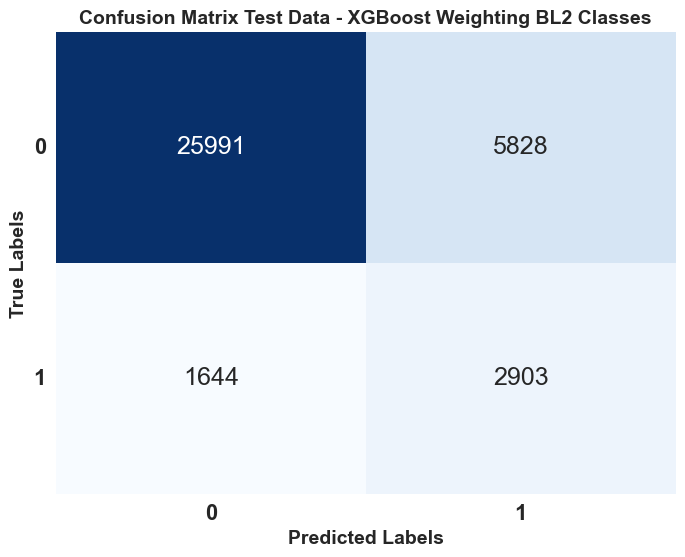

In [290]:
y_hat = model_BL2_class.predict(X_test)

# Calcular la precisión
accuracy = accuracy_score(y_test, y_hat)  # El orden correcto es y_test, y_hat
print(f'Accuracy: {accuracy:.4f}')

# Reporte detallado
print(classification_report(y_test, y_hat))  # El orden correcto es y_test, y_hat

# Crear la matriz de confusión
conf_matrix = confusion_matrix(y_test, y_hat)

# Visualización gráfica de la matriz de confusión
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", cbar=False, xticklabels=np.unique(y_test), yticklabels=np.unique(y_test), annot_kws={"size": 18})
plt.title('Confusion Matrix Test Data - XGBoost Weighting BL2 Classes', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Labels', fontsize=14, fontweight='bold')
plt.ylabel('True Labels', fontsize=14, fontweight='bold')
plt.xticks(rotation=0, fontsize=16, fontweight='bold')
plt.yticks(rotation=0, fontsize=16, fontweight='bold')
plt.show()

##### Classification Report

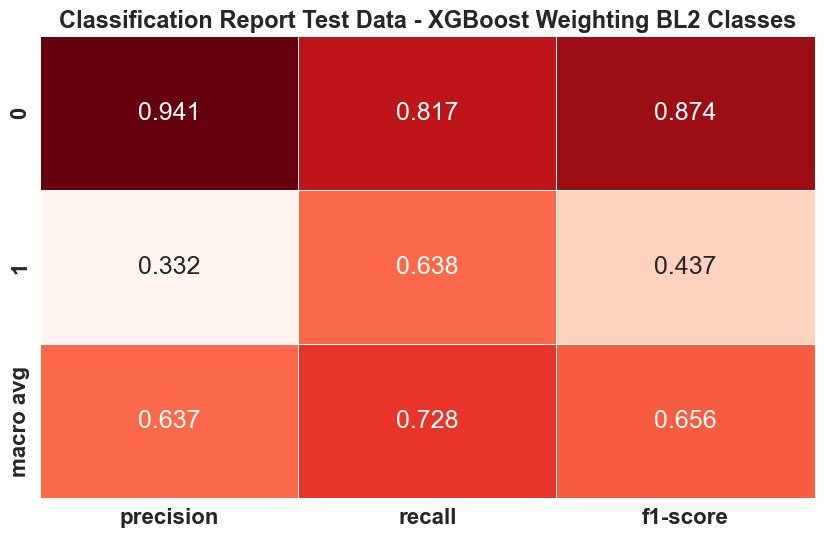

In [291]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report
import pandas as pd

# Generar el reporte de clasificación en formato de diccionario
report = classification_report(y_test, y_hat, output_dict=True)

# Convertir el reporte a un DataFrame
df_report = pd.DataFrame(report).transpose()

# Eliminar filas no deseadas si existen en el reporte
df_report = df_report.drop(['accuracy', 'weighted avg'], axis=0, errors='ignore')

# Redondear las métricas a tres decimales
df_report = df_report.round(3)

# Visualización del reporte de clasificación en un heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df_report[['precision', 'recall', 'f1-score']], annot=True, cmap="Reds", fmt='.3f', linewidths=0.5, cbar=False, annot_kws={"size": 18})

# Ajustes visuales
plt.title('Classification Report Test Data - XGBoost Weighting BL2 Classes', fontsize=17, fontweight='bold')
plt.yticks(fontsize=16, fontweight='bold') 
plt.xticks(fontsize=16, fontweight='bold')
plt.show()

#### Test Data 2025

In [292]:
X_test = df_blast_2025_BL2_class.drop(columns=['BL'])  # Todas las columnas excepto 'BL'
y_test = df_blast_2025_BL2_class['BL']  # Solo la columna 'BL'
y_test = y_test.astype(float)  # Si tiene valores como strings de números (e.g., '1.0', '2.0')

# Convertir a entero
y_test = y_test.astype(int)
y_test = y_test - 1

# Verificar las dimensiones
print("Shape de X_test:", X_test.shape)
print("Shape de y_test:", y_test.shape)

Shape de X_test: (28149, 8)
Shape de y_test: (28149,)


##### Confision Matrix

Accuracy: 0.7349
              precision    recall  f1-score   support

           0       0.81      0.80      0.81     19356
           1       0.57      0.59      0.58      8793

    accuracy                           0.73     28149
   macro avg       0.69      0.69      0.69     28149
weighted avg       0.74      0.73      0.74     28149



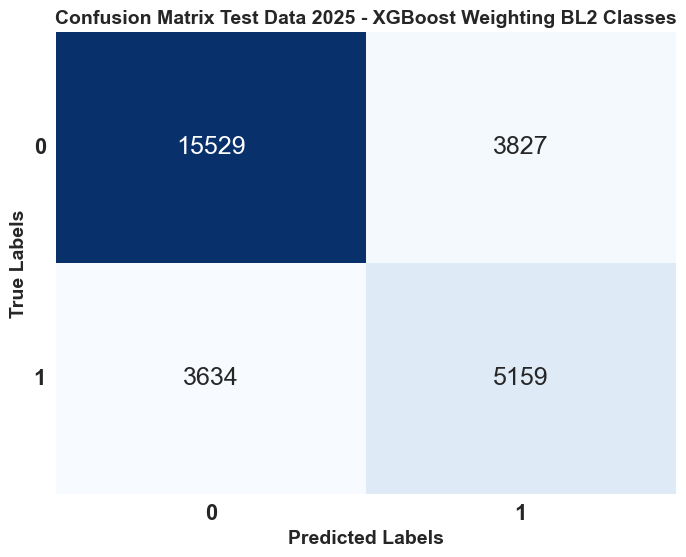

In [293]:
y_hat = model_BL2_class.predict(X_test)

# Calcular la precisión
accuracy = accuracy_score(y_test, y_hat)  # El orden correcto es y_test, y_hat
print(f'Accuracy: {accuracy:.4f}')

# Reporte detallado
print(classification_report(y_test, y_hat))  # El orden correcto es y_test, y_hat

# Crear la matriz de confusión
conf_matrix = confusion_matrix(y_test, y_hat)

# Visualización gráfica de la matriz de confusión
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", cbar=False, xticklabels=np.unique(y_test), yticklabels=np.unique(y_test), annot_kws={"size": 18})
plt.title('Confusion Matrix Test Data 2025 - XGBoost Weighting BL2 Classes', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Labels', fontsize=14, fontweight='bold')
plt.ylabel('True Labels', fontsize=14, fontweight='bold')
plt.xticks(rotation=0, fontsize=16, fontweight='bold')
plt.yticks(rotation=0, fontsize=16, fontweight='bold')
plt.show()

##### Classification Report

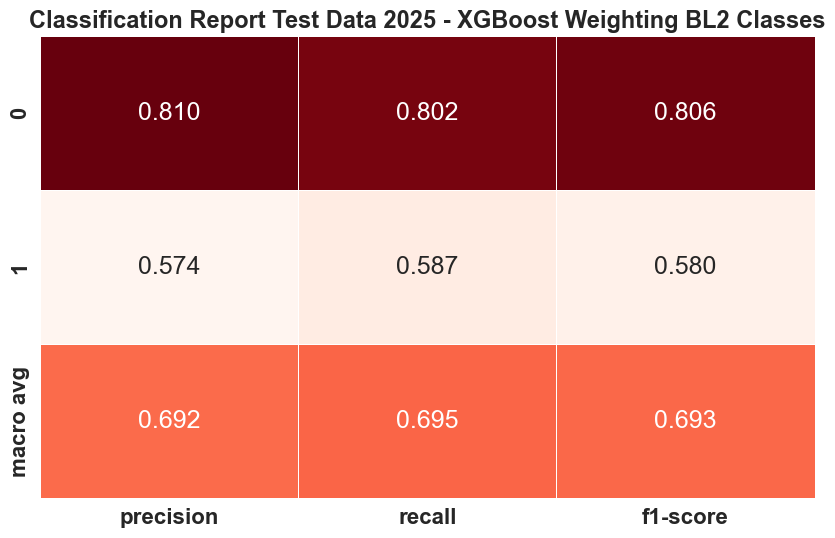

In [294]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report
import pandas as pd

# Generar el reporte de clasificación en formato de diccionario
report = classification_report(y_test, y_hat, output_dict=True)

# Convertir el reporte a un DataFrame
df_report = pd.DataFrame(report).transpose()

# Eliminar filas no deseadas si existen en el reporte
df_report = df_report.drop(['accuracy', 'weighted avg'], axis=0, errors='ignore')

# Redondear las métricas a tres decimales
df_report = df_report.round(3)

# Visualización del reporte de clasificación en un heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df_report[['precision', 'recall', 'f1-score']], annot=True, cmap="Reds", fmt='.3f', linewidths=0.5, cbar=False, annot_kws={"size": 18})

# Ajustes visuales
plt.title('Classification Report Test Data 2025 - XGBoost Weighting BL2 Classes', fontsize=17, fontweight='bold')
plt.yticks(fontsize=16, fontweight='bold') 
plt.xticks(fontsize=16, fontweight='bold')  
plt.show()

### 3 Classes

#### Train Data 

In [295]:
# Dividir el dataset en X_train_unb e y_train_unb
X_train_unb = df_train_BL3_class.drop(columns=['BL'])  # Todas las columnas excepto 'BL'
y_train_unb = df_train_BL3_class['BL']  # Solo la columna 'BL'
y_train_unb = y_train_unb.astype(float)  # Si tiene valores como strings de números (e.g., '1.0', '2.0')

# Convertir a entero
y_train_unb = y_train_unb.astype(int)
y_train_unb = y_train_unb - 1

# Verificar las dimensiones
print("Shape de X_train_unb:", X_train_unb.shape)
print("Shape de y_train_unb:", y_train_unb.shape)

Shape de X_train_unb: (84851, 8)
Shape de y_train_unb: (84851,)


In [296]:
y_train_unb.unique()

array([0, 2, 1])

#### Create Model

In [297]:
# Calcular el ratio para scale_pos_weight
# scale_pos_weight = número de instancias negativas / número de instancias positivas
neg_count = (y_train_unb == 0).sum()
pos_count = (y_train_unb == 1).sum()
scale_pos_weight = neg_count / pos_count

# Crear el modelo de XGBoost 2 clases
"""
model_BL2_class = xgb.XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    objective='binary:logistic',
    eval_metric='auc',  # Otras opciones: 'auc', 'error'
    use_label_encoder=False,
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)
"""

# Crear el modelo de XGBoost 3 clases

model_BL3_class = xgb.XGBClassifier(
    objective='multi:softprob',  # Clasificación multiclase con probabilidades
    num_class=3,                 # Especificar el número de clases
    eval_metric='mlogloss',      # Métrica para multiclase (log loss)
    use_label_encoder=False,
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)


# Entrenar el modelo
model_BL3_class.fit(X_train_unb, y_train_unb)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None, num_class=3, ...)

#### Learning Curve 

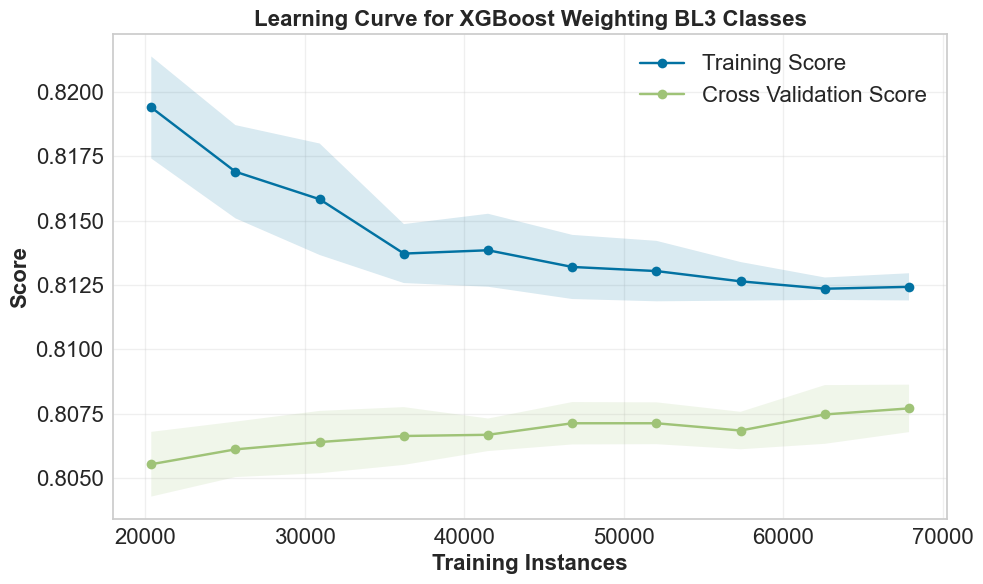

In [298]:
# --- Learning curve computation ---
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Choose scoring:
# - If your plot is accuracy-like, use scoring="accuracy"
# - If you want AUC (matches eval_metric='auc'), use scoring="roc_auc"
train_sizes = np.linspace(0.3, 1.0, 10)

sizes, train_scores, val_scores = learning_curve(
    estimator=model_BL3_class,
    X=X_train_unb,
    y=y_train_unb,
    train_sizes=train_sizes,
    cv=cv,
    scoring="accuracy",         # or "roc_auc"  
    n_jobs=-1,
    shuffle=True,
    random_state=42
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

# --- Plot (match the style in your image) ---
plt.figure(figsize=(10, 6))

# Training curve
plt.plot(sizes, train_mean, marker="o", label="Training Score")
plt.fill_between(sizes, train_mean - train_std, train_mean + train_std, alpha=0.15)

# Cross-validation curve
plt.plot(sizes, val_mean, marker="o", label="Cross Validation Score")
plt.fill_between(sizes, val_mean - val_std, val_mean + val_std, alpha=0.15)

plt.title("Learning Curve for XGBoost Weighting BL3 Classes", fontsize=16, fontweight='bold')
plt.xlabel("Training Instances", fontsize=16, fontweight='bold')
plt.ylabel("Score", fontsize=16, fontweight='bold')
plt.yticks(fontsize=16) 
plt.xticks(fontsize=16)
plt.legend(loc="upper right", fontsize=16)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### Model Parameters

In [299]:
complexity_info = xgb_complexity(model_BL3_class)
print(complexity_info)

{'xgb_n_trees': 300, 'xgb_total_nodes': 17242, 'xgb_total_leaves': 8771, 'complexity': 17242}


#### Test Data

In [300]:
X_test = df_test_BL3_class.drop(columns=['BL'])  # Todas las columnas excepto 'BL'
y_test = df_test_BL3_class['BL']  # Solo la columna 'BL'
y_test = y_test.astype(float)  # Si tiene valores como strings de números (e.g., '1.0', '2.0')

# Convertir a entero
y_test = y_test.astype(int)
y_test = y_test - 1

# Verificar las dimensiones
print("Shape de X_test:", X_test.shape)
print("Shape de y_test:", y_test.shape)

Shape de X_test: (36366, 8)
Shape de y_test: (36366,)


##### Confision Matrix

Accuracy: 0.8083
              precision    recall  f1-score   support

           0       0.82      0.99      0.90     28901
           1       0.48      0.05      0.08      5258
           2       0.59      0.26      0.36      2207

    accuracy                           0.81     36366
   macro avg       0.63      0.43      0.45     36366
weighted avg       0.76      0.81      0.75     36366



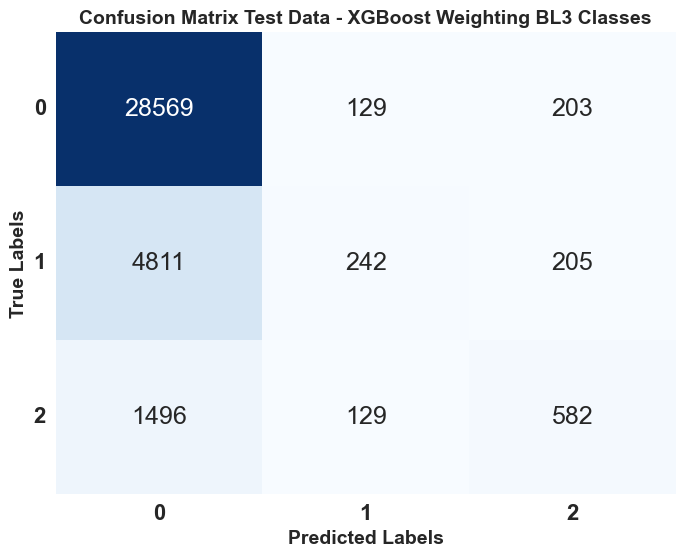

In [301]:
y_hat = model_BL3_class.predict(X_test)

# Calcular la precisión
accuracy = accuracy_score(y_test, y_hat)  # El orden correcto es y_test, y_hat
print(f'Accuracy: {accuracy:.4f}')

# Reporte detallado
print(classification_report(y_test, y_hat))  # El orden correcto es y_test, y_hat

# Crear la matriz de confusión
conf_matrix = confusion_matrix(y_test, y_hat)

# Visualización gráfica de la matriz de confusión
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", cbar=False, xticklabels=np.unique(y_test), yticklabels=np.unique(y_test), annot_kws={"size": 18})
plt.title('Confusion Matrix Test Data - XGBoost Weighting BL3 Classes', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Labels', fontsize=14, fontweight='bold')
plt.ylabel('True Labels', fontsize=14, fontweight='bold')
plt.xticks(rotation=0, fontsize=16, fontweight='bold')
plt.yticks(rotation=0, fontsize=16, fontweight='bold')
plt.show()

##### Classification Report

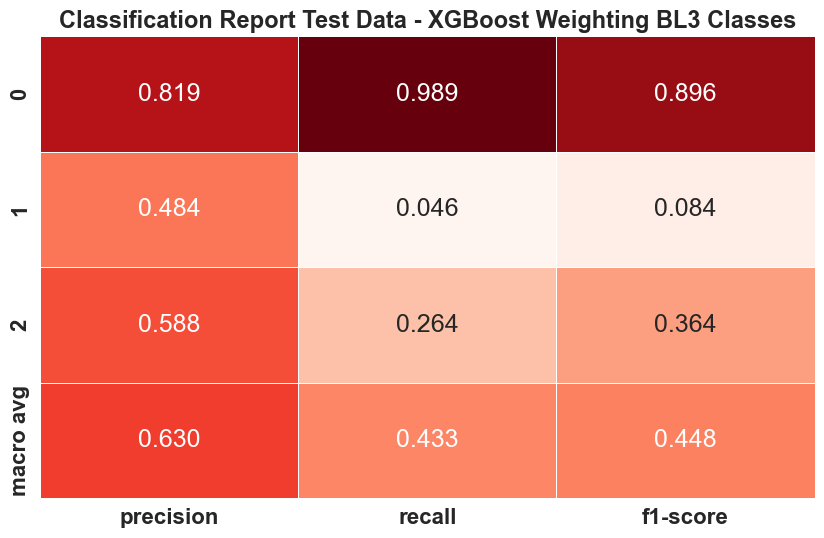

In [302]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report
import pandas as pd

# Generar el reporte de clasificación en formato de diccionario
report = classification_report(y_test, y_hat, output_dict=True)

# Convertir el reporte a un DataFrame
df_report = pd.DataFrame(report).transpose()

# Eliminar filas no deseadas si existen en el reporte
df_report = df_report.drop(['accuracy', 'weighted avg'], axis=0, errors='ignore')

# Redondear las métricas a tres decimales
df_report = df_report.round(3)

# Visualización del reporte de clasificación en un heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df_report[['precision', 'recall', 'f1-score']], annot=True, cmap="Reds", fmt='.3f', linewidths=0.5, cbar=False, annot_kws={"size": 18})

# Ajustes visuales
plt.title('Classification Report Test Data - XGBoost Weighting BL3 Classes', fontsize=17, fontweight='bold')
plt.yticks(fontsize=16, fontweight='bold')
plt.xticks(fontsize=16, fontweight='bold')
plt.show()

#### Test Data 2025

In [303]:
X_test = df_blast_2025_BL3_class.drop(columns=['BL'])  # Todas las columnas excepto 'BL'
y_test = df_blast_2025_BL3_class['BL']  # Solo la columna 'BL'
y_test = y_test.astype(float)  # Si tiene valores como strings de números (e.g., '1.0', '2.0')

# Convertir a entero
y_test = y_test.astype(int)
y_test = y_test - 1

# Verificar las dimensiones
print("Shape de X_test:", X_test.shape)
print("Shape de y_test:", y_test.shape)

Shape de X_test: (28149, 8)
Shape de y_test: (28149,)


##### Confision Matrix

Accuracy: 0.5305
              precision    recall  f1-score   support

           0       0.54      0.96      0.69     14250
           1       0.37      0.06      0.11     10275
           2       0.52      0.16      0.25      3624

    accuracy                           0.53     28149
   macro avg       0.48      0.40      0.35     28149
weighted avg       0.48      0.53      0.42     28149



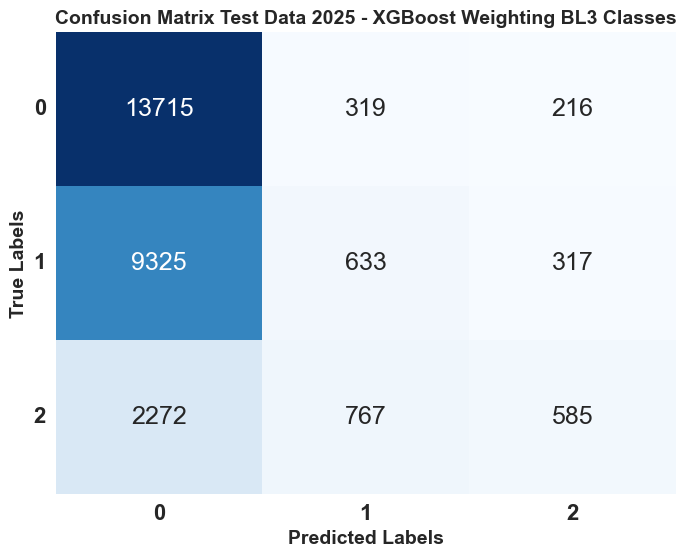

In [304]:
y_hat = model_BL3_class.predict(X_test)

# Calcular la precisión
accuracy = accuracy_score(y_test, y_hat)  # El orden correcto es y_test, y_hat
print(f'Accuracy: {accuracy:.4f}')

# Reporte detallado
print(classification_report(y_test, y_hat))  # El orden correcto es y_test, y_hat

# Crear la matriz de confusión
conf_matrix = confusion_matrix(y_test, y_hat)

# Visualización gráfica de la matriz de confusión
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", cbar=False, xticklabels=np.unique(y_test), yticklabels=np.unique(y_test), annot_kws={"size": 18})
plt.title('Confusion Matrix Test Data 2025 - XGBoost Weighting BL3 Classes', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Labels', fontsize=14, fontweight='bold')
plt.ylabel('True Labels', fontsize=14, fontweight='bold')
plt.xticks(rotation=0, fontsize=16, fontweight='bold')
plt.yticks(rotation=0, fontsize=16, fontweight='bold')
plt.show()

##### Classification Report

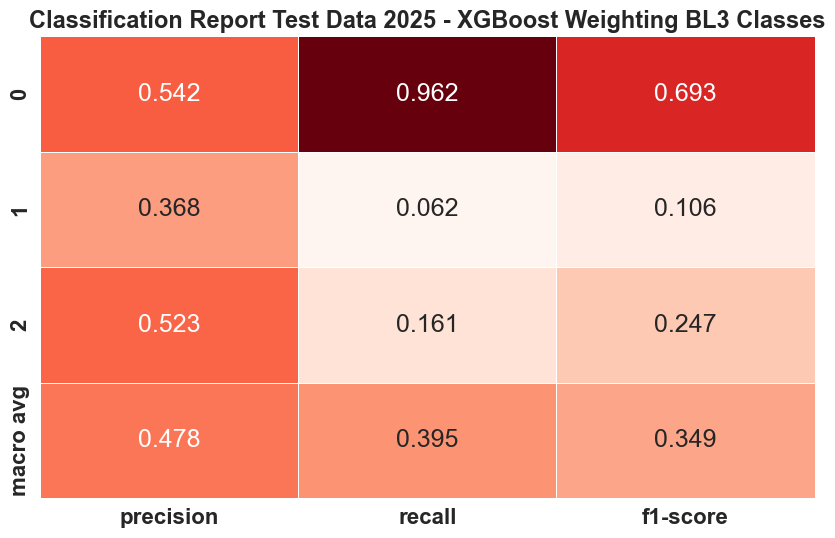

: 

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report
import pandas as pd

# Generar el reporte de clasificación en formato de diccionario
report = classification_report(y_test, y_hat, output_dict=True)

# Convertir el reporte a un DataFrame
df_report = pd.DataFrame(report).transpose()

# Eliminar filas no deseadas si existen en el reporte
df_report = df_report.drop(['accuracy', 'weighted avg'], axis=0, errors='ignore')

# Redondear las métricas a tres decimales
df_report = df_report.round(3)

# Visualización del reporte de clasificación en un heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df_report[['precision', 'recall', 'f1-score']], annot=True, cmap="Reds", fmt='.3f', linewidths=0.5, cbar=False, annot_kws={"size": 18})

# Ajustes visuales
plt.title('Classification Report Test Data 2025 - XGBoost Weighting BL3 Classes', fontsize=17, fontweight='bold')
plt.yticks(fontsize=16, fontweight='bold')
plt.xticks(fontsize=16, fontweight='bold')
plt.show()

# Load Model

In [66]:
# Correct the path
path = r"D:\OneDrive - CGIAR\Documents\Projects\Rice\BLAST PROJECT\2025\CODE\models"

# Join the path and model name safely
name_model = 'Blast_5'
full_path = os.path.join(path, name_model)

xgboost_model = load_model(full_path)

Transformation Pipeline and Model Successfully Loaded


In [67]:
print(xgboost_model)

Pipeline(memory=FastMemory(location=C:\Users\RGUERR~1\AppData\Local\Temp\joblib),
         steps=[('label_encoding',
                 TransformerWrapperWithInverse(exclude=None, include=None,
                                               transformer=LabelEncoder())),
                ('numerical_imputer',
                 TransformerWrapper(exclude=None,
                                    include=['NDRE_MEAN', 'NDVI_MEAN',
                                             'GNDVI_MEAN', 'BNDVI_MEAN',
                                             'NDREI_MEAN', 'NPCI_MEAN',
                                             'GRVI_MEAN', 'NGBDI_MEA...
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
            

# Valid Model

In [68]:
y_pred = predict_model(xgboost_model, data=df_blast_2025_BL2_class)
y_pred

KeyError: "['CH_MEAN', 'CV_MEAN', 'CC_%', 'CC_mt2'] not in index"

              precision    recall  f1-score   support

           1       0.79      0.80      0.79     19356
           2       0.54      0.53      0.53      8793

    accuracy                           0.71     28149
   macro avg       0.66      0.66      0.66     28149
weighted avg       0.71      0.71      0.71     28149



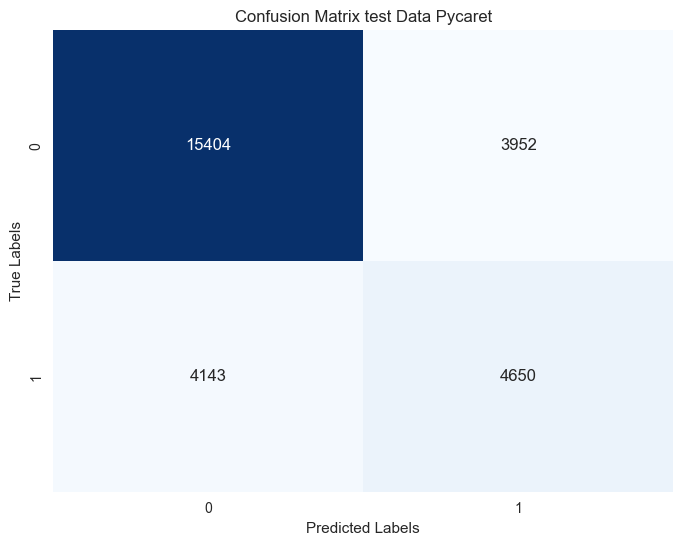

In [ ]:
# Extraer las etiquetas verdaderas y las predicciones
y_true = df_blast_2025_BL2_class['BL']  # Etiquetas verdaderas
y_true = y_true.astype(int)

y_predicted = y_pred['prediction_label']  # Predicciones

# Generar la matriz de confusión
conf_matrix = confusion_matrix(y_true, y_predicted)

# Generar el reporte de clasificación (opcional)
print(classification_report(y_true, y_predicted))

# Visualizar la matriz de confusión usando seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix test Data Pycaret')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

# Fin